# PCOS Clinical EDA — Enhanced Visual Edition

## Introduction
This notebook is the main clinical PCOS EDA. It uses clearer charts, cleaner labels, and one matching style across all 36 questions.

Data source: `cleaned_data/PCOS_full_cleaned.csv`.


## 1 · Reproducibility Setup and Path Configuration


In [1]:
# ── Core imports ─────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

np.random.seed(42)

# ── Enhanced visual theme ─────────────────────────────────────────────────
PALETTE = {
    'neg':    '#3b82f6',
    'pos':    '#e76f51',
    'neg_lt': '#93c5fd',
    'pos_lt': '#fdba74',
    'teal':   '#14b8a6',
    'slate':  '#334155',
    'cream':  '#f8f5f0',
    'grid':   '#e2e8f0',
    'accent': ['#2a9d8f', '#e9c46a', '#6d597a', '#264653'],
}

PCOS_LABEL_ORDER   = ['PCOS Negative', 'PCOS Positive']
PCOS_LABEL_PALETTE = {'PCOS Negative': PALETTE['neg'], 'PCOS Positive': PALETTE['pos']}

RC = {
    'figure.dpi':            140,
    'figure.facecolor':      'white',
    'axes.facecolor':        '#f9fafb',
    'axes.edgecolor':        '#cbd5e1',
    'axes.linewidth':        0.8,
    'axes.titlesize':        13,
    'axes.titleweight':      'bold',
    'axes.titlepad':         10,
    'axes.labelsize':        10.5,
    'axes.labelcolor':       '#334155',
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             True,
    'grid.color':            '#e2e8f0',
    'grid.linewidth':        0.6,
    'grid.alpha':            0.8,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    'xtick.color':           '#334155',
    'ytick.color':           '#334155',
    'legend.fontsize':       9,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#cbd5e1',
    'legend.borderpad':      0.6,
    'lines.linewidth':       1.8,
    'patch.linewidth':       0.7,
}
mpl.rcParams.update(RC)

# ── Path resolution ───────────────────────────────────────────────────────
def resolve_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, current.parent, current.parent.parent]:
        if (candidate / 'cleaned_data').exists() and (candidate / 'images').exists():
            return candidate
    return current

PROJECT_ROOT = resolve_project_root()
DATA_PATH    = PROJECT_ROOT / 'cleaned_data' / 'PCOS_full_cleaned.csv'
IMAGE_DIR    = PROJECT_ROOT / 'images' / 'eda' / 'clinical'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'Image dir    : {IMAGE_DIR}')


Project root : C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic
Data path    : C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_full_cleaned.csv
Image dir    : C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\eda\clinical


## 2 · Helper Functions


In [2]:
def save_figure(fig, slug):
    path = IMAGE_DIR / slug
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    return path

def finish(ax, grid_axis='y'):
    sns.despine(ax=ax)
    ax.grid(axis=grid_axis, color=PALETTE['grid'], linewidth=0.6, alpha=0.9)
    ax.set_axisbelow(True)
    if ax.get_legend():
        ax.get_legend().set_title('')

def grouped_numeric_summary(data, feature):
    return (data.groupby('pcos_label')[feature]
               .agg(['count','mean','median','std','min','max'])
               .rename(columns={'count':'n'})
               .round(3).reset_index())

def grouped_binary_prevalence(data, feature):
    s = (data.groupby('pcos_label')[feature]
            .agg(['count','sum','mean'])
            .rename(columns={'count':'n','sum':'positive_count','mean':'prevalence'})
            .reset_index())
    s['prevalence_pct'] = (s['prevalence'] * 100).round(1)
    return s[['pcos_label','n','positive_count','prevalence_pct']]

def plot_numeric_by_target(data, feature, ylabel, title, slug,
                           kind='violin_strip', figsize=(7, 4.4),
                           log_scale=False, discrete=False):
    fig, ax = plt.subplots(figsize=figsize)
    neg = data.loc[data['pcos_label']=='PCOS Negative', feature].dropna()
    pos = data.loc[data['pcos_label']=='PCOS Positive',  feature].dropna()
    if kind == 'violin_strip':
        sns.violinplot(data=data, x='pcos_label', y=feature,
                       order=PCOS_LABEL_ORDER, palette=PCOS_LABEL_PALETTE,
                       cut=0, inner=None, linewidth=1.2, ax=ax, saturation=0.85)
        for coll in ax.collections:
            coll.set_alpha(0.72)
        sns.stripplot(data=data, x='pcos_label', y=feature,
                      order=PCOS_LABEL_ORDER, color=PALETTE['slate'],
                      alpha=0.22, size=2.8, jitter=0.22, ax=ax)
        for i, grp in enumerate([neg, pos]):
            ax.hlines(grp.mean(), i-0.38, i+0.38,
                      colors='white', linewidth=2.4, zorder=6)
            ax.hlines(grp.mean(), i-0.38, i+0.38,
                      colors=PALETTE['slate'], linewidth=1.2,
                      linestyles='--', zorder=7)
        ax.set_xlabel('')
    elif kind == 'boxen_strip':
        sns.boxenplot(data=data, x='pcos_label', y=feature,
                      order=PCOS_LABEL_ORDER, palette=PCOS_LABEL_PALETTE,
                      linewidth=0.9, ax=ax, saturation=0.85)
        for patch in ax.patches:
            patch.set_alpha(0.78)
        sns.stripplot(data=data, x='pcos_label', y=feature,
                      order=PCOS_LABEL_ORDER, color=PALETTE['slate'],
                      alpha=0.18, size=2.5, jitter=0.18, ax=ax)
        ax.set_xlabel('')
    elif kind == 'kde':
        for label, grp in zip(PCOS_LABEL_ORDER, [neg, pos]):
            sns.kdeplot(grp, fill=True, alpha=0.22, linewidth=2,
                        label=label, color=PCOS_LABEL_PALETTE[label], ax=ax)
            ax.axvline(grp.median(), color=PCOS_LABEL_PALETTE[label],
                       linewidth=1.4, linestyle='--', alpha=0.9)
        ax.set_xlabel(ylabel); ax.set_ylabel('Density')
        ax.legend(); ax.set_title(title)
        finish(ax, 'both')
        save_figure(fig, slug); plt.show(); return
    elif kind == 'hist_hue':
        sns.histplot(data=data, x=feature,
                     hue='pcos_label', hue_order=PCOS_LABEL_ORDER,
                     palette=PCOS_LABEL_PALETTE,
                     bins=None if discrete else 24, discrete=discrete,
                     stat='density', common_norm=False,
                     multiple='dodge' if discrete else 'layer',
                     alpha=0.35, edgecolor='white', linewidth=0.8, ax=ax)
        if log_scale: ax.set_xscale('log')
        ax.set_xlabel(ylabel); ax.set_ylabel('Density')
        ax.set_title(title); finish(ax, 'both')
        save_figure(fig, slug); plt.show(); return
    elif kind == 'ecdf_hue':
        for label, grp in zip(PCOS_LABEL_ORDER, [neg, pos]):
            sns.ecdfplot(grp, label=label,
                         color=PCOS_LABEL_PALETTE[label], linewidth=2, ax=ax)
        if log_scale: ax.set_xscale('log')
        ax.set_xlabel(ylabel); ax.set_ylabel('Cumulative Proportion')
        ax.legend(); ax.set_title(title)
        finish(ax, 'both')
        save_figure(fig, slug); plt.show(); return
    ax.set_ylabel(ylabel); ax.set_title(title)
    finish(ax)
    save_figure(fig, slug); plt.show()

def plot_binary_prevalence(summary, title, slug, ylabel='Prevalence (%)'):
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    bars = ax.bar(summary['pcos_label'], summary['prevalence_pct'],
                  color=[PCOS_LABEL_PALETTE[l] for l in summary['pcos_label']],
                  width=0.52, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, summary['prevalence_pct']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=PALETTE['slate'])
    ax.set_ylim(0, summary['prevalence_pct'].max() * 1.22)
    ax.set_xlabel(''); ax.set_ylabel(ylabel); ax.set_title(title)
    finish(ax)
    save_figure(fig, slug); plt.show()

print('Helper functions loaded.')


Helper functions loaded.


## 3 · Data Loading and Feature Preparation


In [3]:
df = pd.read_csv(DATA_PATH)

required_columns = [
    'pcos_y_n','age_yrs','weight_kg','height_cm','bmi',
    'pulse_rate_bpm','respiratory_rate_breaths_min','hb_g_dl',
    'cycle_regularity_code','cycle_length_days','waist_hip_ratio','rbs_mg_dl',
    'weight_gain_y_n','hair_growth_y_n','skin_darkening_y_n',
    'hair_loss_y_n','pimples_y_n','fast_food_y_n','regular_exercise_y_n',
    'systolic_bp_mmhg','diastolic_bp_mmhg',
    'follicle_no_left','follicle_no_right',
    'avg_follicle_size_left_mm','avg_follicle_size_right_mm','endometrium_mm',
]
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

binary_cols = ['pcos_y_n','weight_gain_y_n','hair_growth_y_n','skin_darkening_y_n',
               'hair_loss_y_n','pimples_y_n','fast_food_y_n','regular_exercise_y_n']
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype(int)
for c in [col for col in required_columns if col not in binary_cols]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['pcos_label'] = df['pcos_y_n'].map({0:'PCOS Negative', 1:'PCOS Positive'})
for c in ['weight_gain_y_n','hair_growth_y_n','skin_darkening_y_n',
          'hair_loss_y_n','pimples_y_n','fast_food_y_n','regular_exercise_y_n']:
    df[f'{c}_label'] = df[c].map({0:'No', 1:'Yes'})

df['total_follicle_count']      = df['follicle_no_left'] + df['follicle_no_right']
df['bmi_category']              = pd.cut(df['bmi'], bins=[0,18.5,25,30,np.inf],
                                          labels=['Underweight','Normal','Overweight','Obese'],
                                          include_lowest=True)
df['bmi_overweight_flag']       = (df['bmi'] >= 25).astype(int)
df['low_exercise_flag']         = (1 - df['regular_exercise_y_n']).astype(int)
df['non_invasive_burden_score'] = (df['weight_gain_y_n'] + df['hair_growth_y_n'] +
                                   df['skin_darkening_y_n'] + df['hair_loss_y_n'] +
                                   df['pimples_y_n'] + df['fast_food_y_n'] +
                                   df['bmi_overweight_flag'] + df['low_exercise_flag'])

print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns.')
display(df.head(3))


Loaded 541 rows x 57 columns.


,pcos_y_n,age_yrs,weight_kg,height_cm,bmi,blood_group_code,pulse_rate_bpm,respiratory_rate_breaths_min,hb_g_dl,cycle_regularity_code,...,skin_darkening_y_n_label,hair_loss_y_n_label,pimples_y_n_label,fast_food_y_n_label,regular_exercise_y_n_label,total_follicle_count,bmi_category,bmi_overweight_flag,low_exercise_flag,non_invasive_burden_score
0,0,28,44.6,152.0,19.300000,15,78.0,22,10.48,2,...,No,No,No,Yes,No,6,Normal,0,1,2
1,0,36,65.0,161.5,24.921163,15,74.0,20,11.70,2,...,No,No,No,No,No,8,Normal,0,1,1
2,1,33,68.8,165.0,25.270891,11,72.0,18,11.80,2,...,No,Yes,Yes,Yes,No,28,Overweight,1,1,5


## 4 · Dataset Overview and Target Distribution

### Q1 · Dataset size, schema, and target balance


,metric,value
0,row_count,541
1,column_count,57
2,numeric_column_count,48
3,missing_cells,0


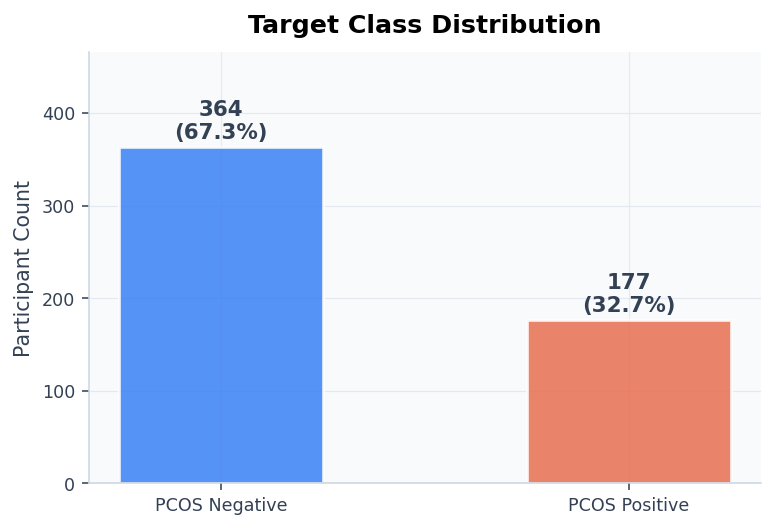

In [4]:
overview = pd.DataFrame({
    'metric': ['row_count','column_count','numeric_column_count','missing_cells'],
    'value':  [df.shape[0], df.shape[1],
               int(df.select_dtypes(include=np.number).shape[1]),
               int(df.isna().sum().sum())],
})
display(overview)

counts = df['pcos_label'].value_counts().reindex(PCOS_LABEL_ORDER)
pcts   = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6.2, 4.0))
bars = ax.bar(counts.index, counts.values,
              color=[PCOS_LABEL_PALETTE[l] for l in counts.index],
              width=0.50, alpha=0.86, edgecolor='white', linewidth=1.4)
for bar, n, p in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
            f'{n:,}\n({p}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=PALETTE['slate'])
ax.set_ylim(0, counts.max() * 1.28)
ax.set_title('Target Class Distribution')
ax.set_xlabel(''); ax.set_ylabel('Participant Count')
finish(ax)
save_figure(fig, 'q01_target_distribution.png')
plt.show()


### Insight
**Scientific interpretation:** The class-balance table shows a moderate imbalance in the clinical cohort, with 364 PCOS-negative participants and 177 PCOS-positive participants. The count chart is therefore showing a meaningful skew toward the negative class without making the positive class rare.

**Simple summary:** There are more non-PCOS patients than PCOS patients in this cleaned clinical dataset.

**Why this matters:** Later screening models should not be judged by accuracy alone, because a model can look accurate while still missing clinically important positive cases.


### Q2 · Core clinical phenotype profile — mean by PCOS status


pcos_label,PCOS Negative,PCOS Positive
age_yrs,32.066,30.124
weight_kg,58.009,62.986
bmi,23.747,25.471
waist_hip_ratio,0.891,0.893
pulse_rate_bpm,73.275,73.831
respiratory_rate_breaths_min,19.201,19.333
hb_g_dl,11.107,11.268
cycle_length_days,5.140,4.559
systolic_bp_mmhg,114.890,114.746
diastolic_bp_mmhg,76.978,77.232


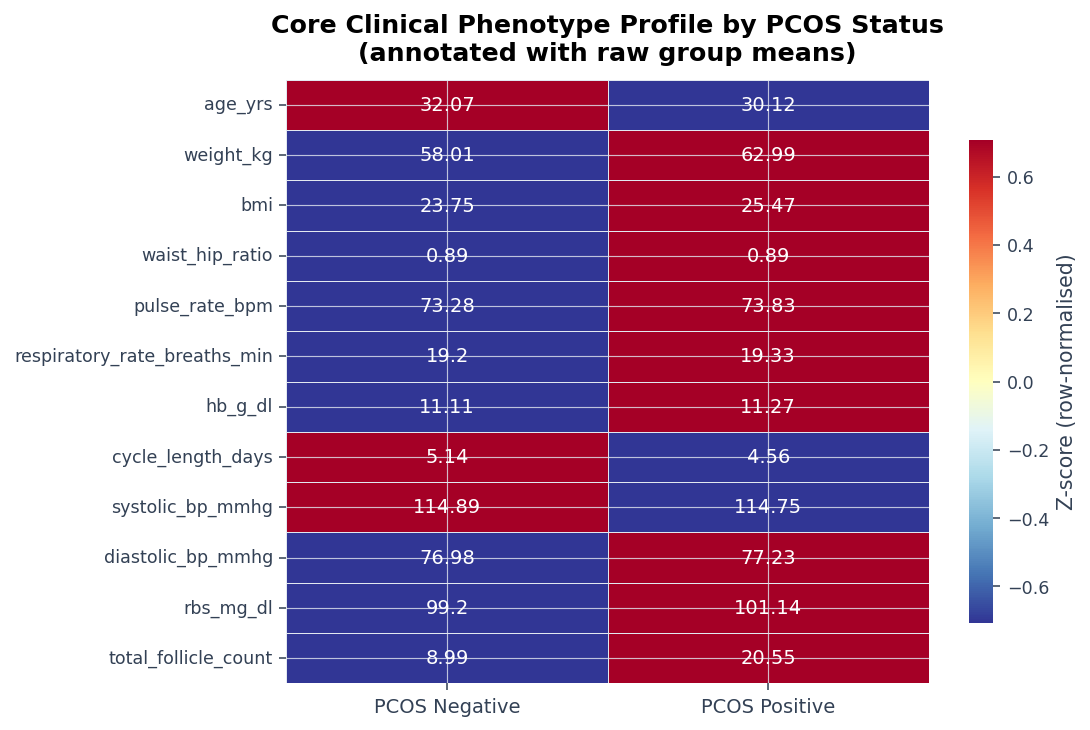

In [5]:
core_features = [
    'age_yrs','weight_kg','bmi','waist_hip_ratio','pulse_rate_bpm',
    'respiratory_rate_breaths_min','hb_g_dl','cycle_length_days',
    'systolic_bp_mmhg','diastolic_bp_mmhg','rbs_mg_dl','total_follicle_count',
]
profile_mean = df.groupby('pcos_label')[core_features].mean().round(3).T
display(profile_mean)

# Row-normalise to z-scores for a fair colour scale
profile_z = (profile_mean
             .subtract(profile_mean.mean(axis=1), axis=0)
             .divide(profile_mean.std(axis=1).replace(0,1), axis=0))

fig, ax = plt.subplots(figsize=(7.4, 5.6))
sns.heatmap(profile_z, annot=profile_mean.round(2), fmt='g',
            cmap='RdYlBu_r', center=0,
            linewidths=0.5, linecolor='#e2e8f0',
            cbar_kws={'label':'Z-score (row-normalised)', 'shrink':0.80},
            ax=ax)
ax.set_title('Core Clinical Phenotype Profile by PCOS Status\n'
             '(annotated with raw group means)')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', rotation=0)
save_figure(fig, 'q02_core_phenotype_heatmap.png')
plt.show()


### Insight
**Scientific interpretation:** The phenotype heatmap shows that the clearest group-level shifts are occurring in adiposity-linked and ovarian features, while pulse rate, respiratory rate, and other general physiologic measures are comparatively stable. Because the heatmap is colour-scaled by relative contrast but annotated with raw means, it is showing both separation strength and direction.

**Simple summary:** The biggest differences appear in weight, BMI, and follicle-related features, not in ordinary vital signs.

**Why this matters:** This supports a PCOS phenotype that is clustering around metabolic and reproductive change rather than broad physiologic instability.


### Section Synthesis
**Cross-chart reading:** The overview and phenotype profile are establishing the baseline story of this cohort: PCOS is not simply a rare label scattered randomly through the data, and the early separation is clustering in body-composition and ovarian measures.

**How the findings relate:** The class distribution tells us to think carefully about missed positives, while the phenotype heatmap tells us where the most promising signal is likely to come from.

**Practical interpretation:** The rest of the notebook should be read as a targeted search for which non-invasive and clinically routine features best explain that broader phenotype shift.


## 5 · Non-Invasive Continuous Features (Q3 – Q14)


### Q03 · Does age differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,32.066,32.0,5.361,20,48
1,PCOS Positive,177,30.124,29.0,5.292,21,47


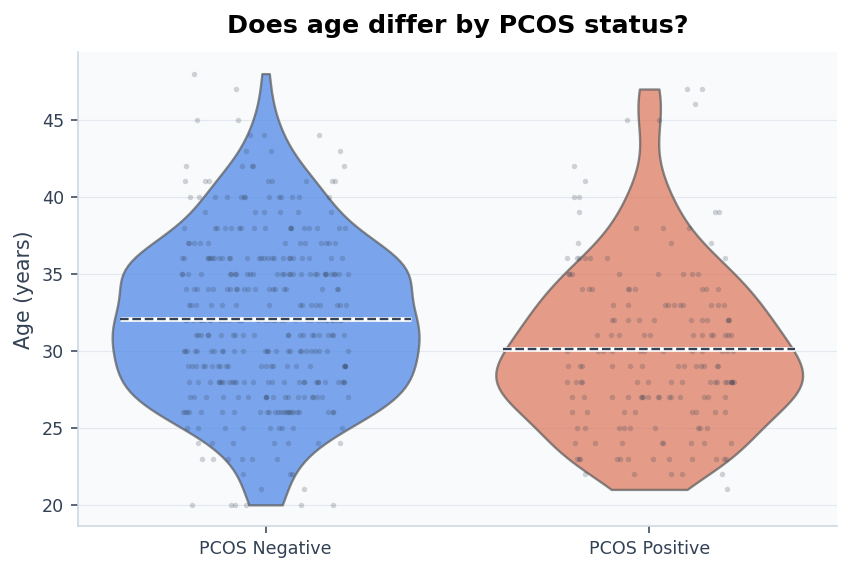

In [6]:
display(grouped_numeric_summary(df, 'age_yrs'))
plot_numeric_by_target(
    data=df, feature='age_yrs', ylabel='Age (years)',
    title='Does age differ by PCOS status?',
    slug='q03_age_yrs_vs_pcos.png',
    kind='violin_strip',
)


### Insight
**Scientific interpretation:** The age summary shows only a small difference between groups, and the violin shapes overlap heavily across most of the range. In this cohort, the PCOS-positive group is slightly younger on average, but age is not creating a strong visual boundary.

**Simple summary:** Age changes a little, but not enough to separate the groups clearly.

**Why this matters:** Age is useful as context, yet it is not behaving like a high-priority standalone screening feature.


### Q04 · Does weight differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,58.009,58.0,10.047,32.0,108.0
1,PCOS Positive,177,62.986,62.0,12.175,31.0,104.0


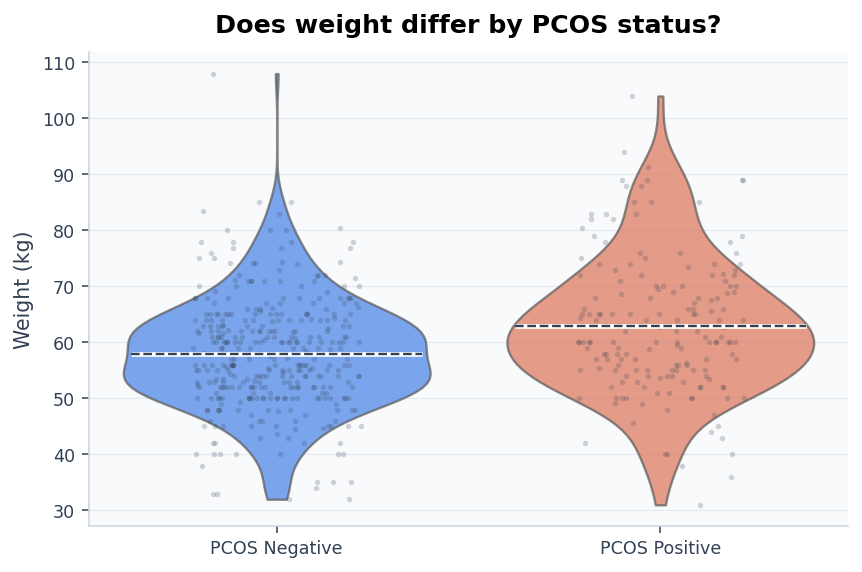

In [7]:
display(grouped_numeric_summary(df, 'weight_kg'))
plot_numeric_by_target(
    data=df, feature='weight_kg', ylabel='Weight (kg)',
    title='Does weight differ by PCOS status?',
    slug='q04_weight_kg_vs_pcos.png',
    kind='violin_strip',
)


### Insight
**Scientific interpretation:** The grouped summary indicates a higher average weight in the PCOS-positive group, and the violin distribution is shifted upward rather than being driven by only a few isolated extremes. This suggests a cohort-wide body-mass difference.

**Simple summary:** PCOS-positive participants tend to be heavier overall.

**Why this matters:** Weight is a simple routine measure, so even a moderate upward shift is useful when building a low-burden screening profile.


### Q05 · Does BMI differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,23.747,23.6,3.759,13.388,38.265
1,PCOS Positive,177,25.471,25.1,4.396,12.418,38.900


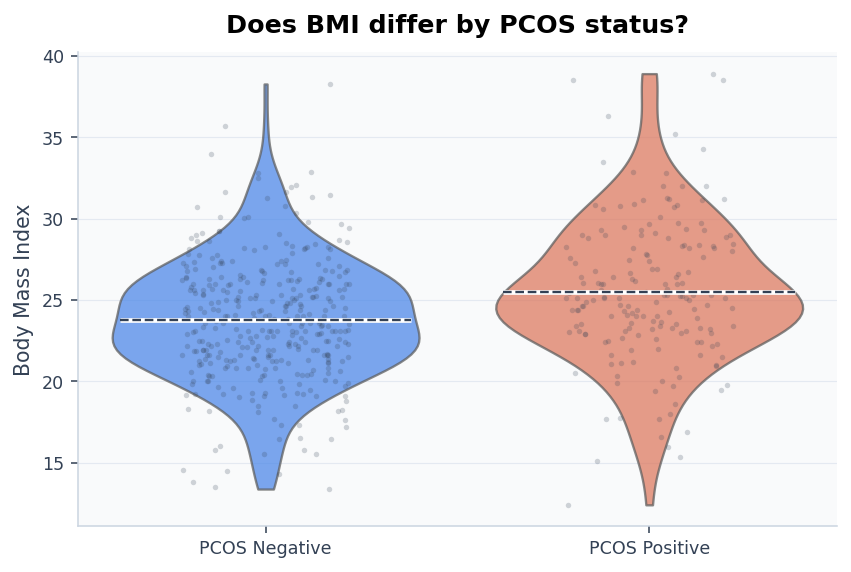

In [8]:
display(grouped_numeric_summary(df, 'bmi'))
plot_numeric_by_target(
    data=df, feature='bmi', ylabel='Body Mass Index',
    title='Does BMI differ by PCOS status?',
    slug='q05_bmi_vs_pcos.png',
    kind='violin_strip',
)


### Insight
**Scientific interpretation:** The summary table and violin plot both show a clearer rightward shift for BMI than for age or weight alone, with the positive group occupying more of the higher-density region at larger values. The overlap is still present, but the central mass is visibly displaced upward.

**Simple summary:** BMI separates the two groups better than many of the other routine measurements.

**Why this matters:** This reinforces BMI as one of the most important non-invasive features for later screening and model design.


### Q06 · Does waist-hip ratio differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,0.891,0.895,0.046,0.777,0.977
1,PCOS Positive,177,0.893,0.897,0.046,0.756,0.979


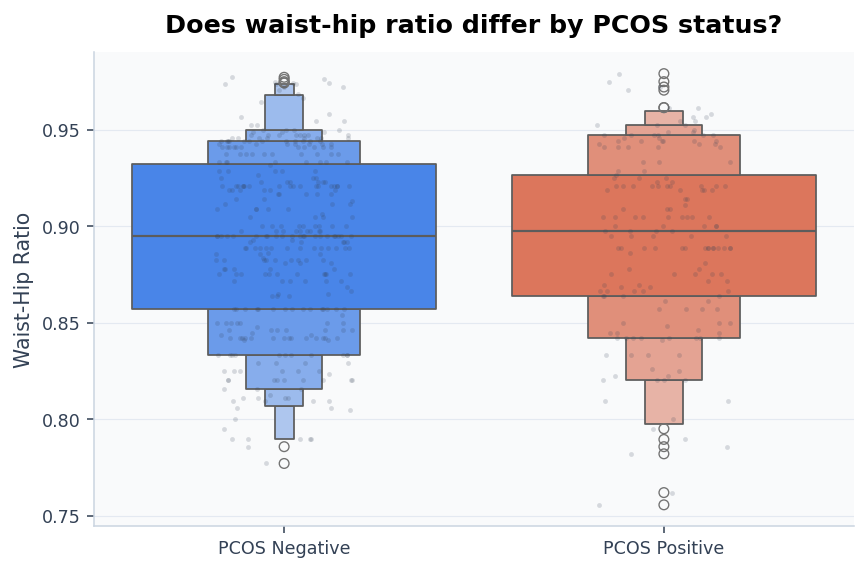

In [9]:
display(grouped_numeric_summary(df, 'waist_hip_ratio'))
plot_numeric_by_target(
    data=df, feature='waist_hip_ratio', ylabel='Waist-Hip Ratio',
    title='Does waist-hip ratio differ by PCOS status?',
    slug='q06_waist_hip_ratio_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** The grouped summary suggests very similar average waist-hip ratio across the two groups, and the boxen plot shows substantial overlap through most of the distribution depth. Any difference is much weaker than the BMI shift seen in the previous chart.

**Simple summary:** Waist-hip ratio is not separating the groups nearly as clearly as BMI.

**Why this matters:** Waist-hip ratio may still add nuance in multivariable modelling, but it does not look strong enough to carry the screening signal on its own.


### Q07 · Does pulse rate differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,73.275,72.0,2.649,70.0,82.0
1,PCOS Positive,177,73.831,72.0,2.731,70.0,82.0


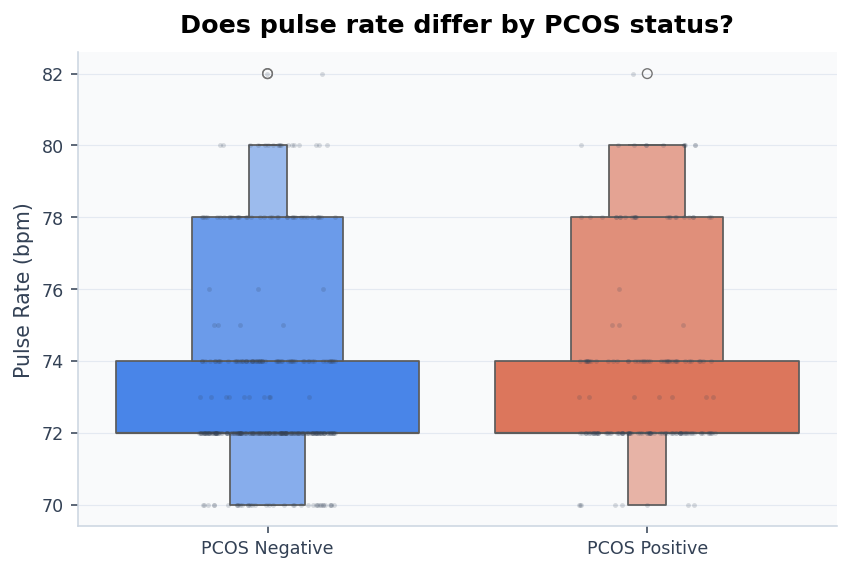

In [10]:
display(grouped_numeric_summary(df, 'pulse_rate_bpm'))
plot_numeric_by_target(
    data=df, feature='pulse_rate_bpm', ylabel='Pulse Rate (bpm)',
    title='Does pulse rate differ by PCOS status?',
    slug='q07_pulse_rate_bpm_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** The pulse-rate summary is nearly identical across groups, and the boxen layers remain heavily overlapping from the centre into the tails. That pattern suggests very limited direct separation by PCOS status.

**Simple summary:** Pulse rate looks almost the same in both groups.

**Why this matters:** Pulse may capture general physiology, but it is not acting like a useful standalone PCOS marker in this cohort.


### Q08 · Does respiratory rate differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,19.201,18.0,1.709,16,28
1,PCOS Positive,177,19.333,20.0,1.647,16,24


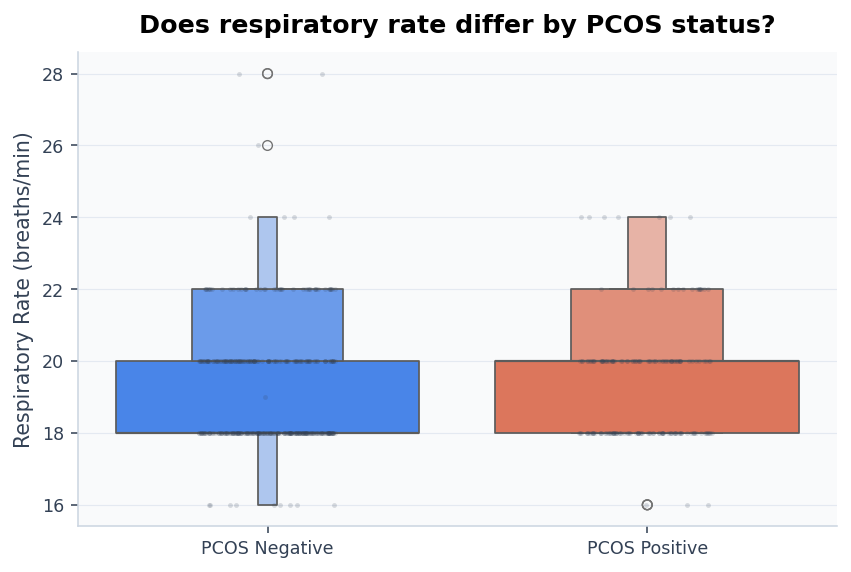

In [11]:
display(grouped_numeric_summary(df, 'respiratory_rate_breaths_min'))
plot_numeric_by_target(
    data=df, feature='respiratory_rate_breaths_min', ylabel='Respiratory Rate (breaths/min)',
    title='Does respiratory rate differ by PCOS status?',
    slug='q08_respiratory_rate_breaths_min_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** Respiratory rate also shows almost identical group means, and the boxen plot reveals very little structural separation beyond ordinary variability. The distribution is behaving like stable background physiology.

**Simple summary:** Breathing rate stays very similar across the two groups.

**Why this matters:** This makes respiratory rate more of a background health measure than a likely screening feature for PCOS.


### Q09 · Does hemoglobin differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,11.107,11.0,0.880,8.5,14.8
1,PCOS Positive,177,11.268,11.0,0.831,9.4,14.0


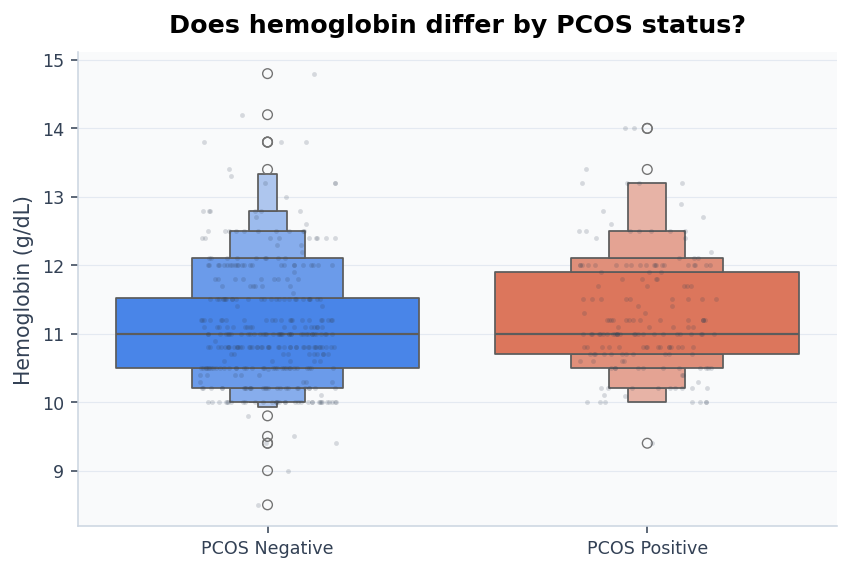

In [12]:
display(grouped_numeric_summary(df, 'hb_g_dl'))
plot_numeric_by_target(
    data=df, feature='hb_g_dl', ylabel='Hemoglobin (g/dL)',
    title='Does hemoglobin differ by PCOS status?',
    slug='q09_hb_g_dl_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** Haemoglobin changes only slightly between groups, and the distribution remains strongly overlapping in the boxen view. There is no evidence here of haemoglobin acting as a dominant differentiator of PCOS status.

**Simple summary:** Haemoglobin is moving only a little and does not clearly split the groups.

**Why this matters:** It is better interpreted as background clinical context than as a headline discriminator for later modelling.


### Q10 · Does cycle-length measure differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,5.140,5.0,1.235,2.0,12.0
1,PCOS Positive,177,4.559,5.0,1.821,2.0,12.0


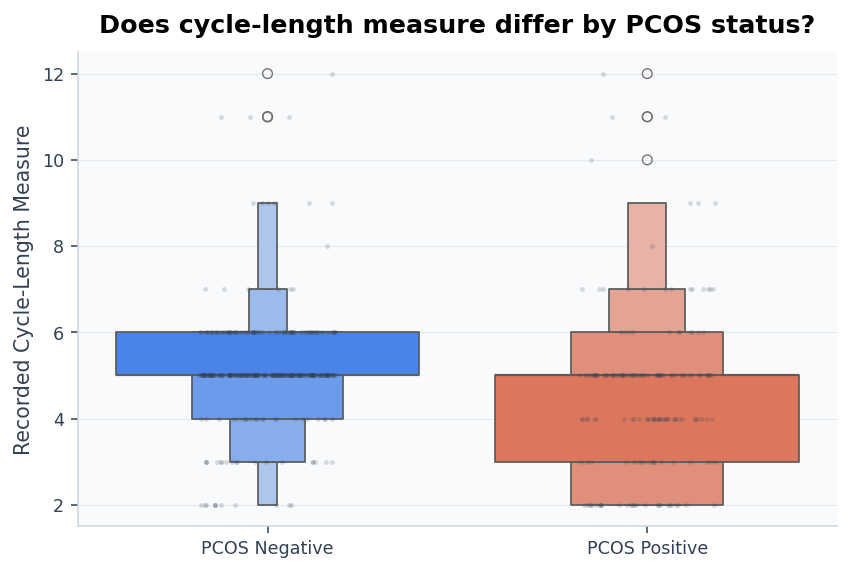

In [13]:
display(grouped_numeric_summary(df, 'cycle_length_days'))
plot_numeric_by_target(
    data=df, feature='cycle_length_days', ylabel='Recorded Cycle-Length Measure',
    title='Does cycle-length measure differ by PCOS status?',
    slug='q10_cycle_length_days_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** The summary table shows that the recorded cycle-length measure differs by PCOS status, and the boxen plot indicates a group shift rather than a purely outlier-driven effect. Because this variable behaves like a short ordered recording rather than a literal calendar-day measure, the safe conclusion is that menstrual-pattern coding differs between groups.

**Simple summary:** The cycle-length measure changes with PCOS status, but it should be read as a recorded cycle pattern, not as a literal number of days.

**Why this matters:** Menstrual-pattern variables are clinically central to PCOS, so this coded shift remains important even without a direct real-world day mapping.


### Q11 · Does cycle_regularity_code differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,2.308,2.0,0.723,2,4
1,PCOS Positive,177,3.079,4.0,1.008,2,5


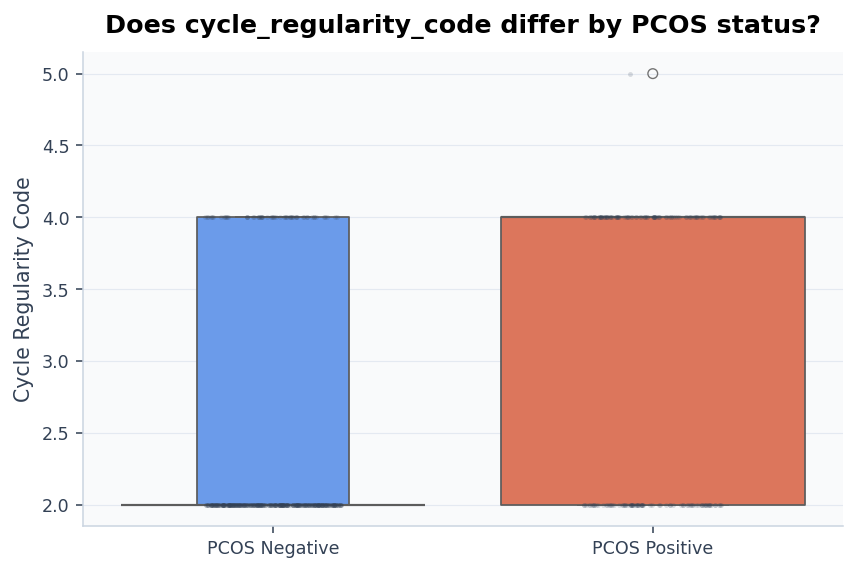

In [14]:
display(grouped_numeric_summary(df, 'cycle_regularity_code'))
plot_numeric_by_target(
    data=df, feature='cycle_regularity_code', ylabel='Cycle Regularity Code',
    title='Does cycle_regularity_code differ by PCOS status?',
    slug='q11_cycle_regularity_code_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** The ordered cycle-regularity code is higher on average in the PCOS-positive group, and the boxen plot shows that the positive distribution is shifted upward through much of its depth. This makes the regularity code more informative than most of the general vital-sign measures.

**Simple summary:** The positive group is clustering at higher cycle-regularity codes.

**Why this matters:** Even without decoding every category, the ordered shift supports menstrual irregularity as a core part of the PCOS phenotype.


### Q12 · Does systolic BP differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,114.890,110.0,6.052,100.0,140.0
1,PCOS Positive,177,114.746,110.0,5.648,100.0,130.0


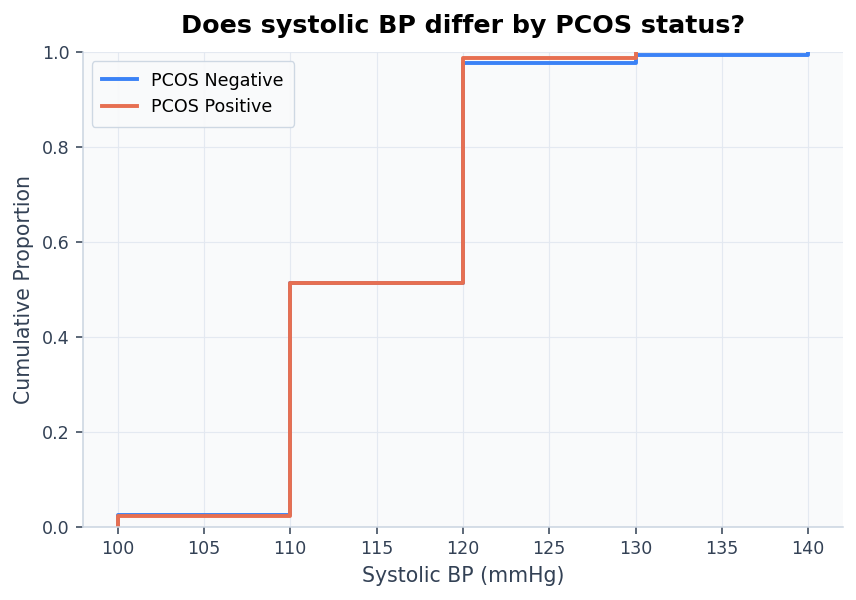

In [15]:
display(grouped_numeric_summary(df, 'systolic_bp_mmhg'))
plot_numeric_by_target(
    data=df, feature='systolic_bp_mmhg', ylabel='Systolic BP (mmHg)',
    title='Does systolic BP differ by PCOS status?',
    slug='q12_systolic_bp_mmhg_vs_pcos.png',
    kind='ecdf_hue',
)


### Insight
**Scientific interpretation:** The ECDF curves for systolic blood pressure track each other closely across most percentiles, which means neither group is consistently dominating the other across the cumulative distribution. Any difference is small relative to the overall overlap.

**Simple summary:** Systolic blood pressure looks very similar in both groups.

**Why this matters:** Blood pressure may still provide heart and metabolic context, but it does not appear to be a sharp PCOS discriminator in this clinical cohort.


### Q13 · Does diastolic BP differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,76.978,80.0,4.832,60.0,100.0
1,PCOS Positive,177,77.232,80.0,4.487,70.0,80.0


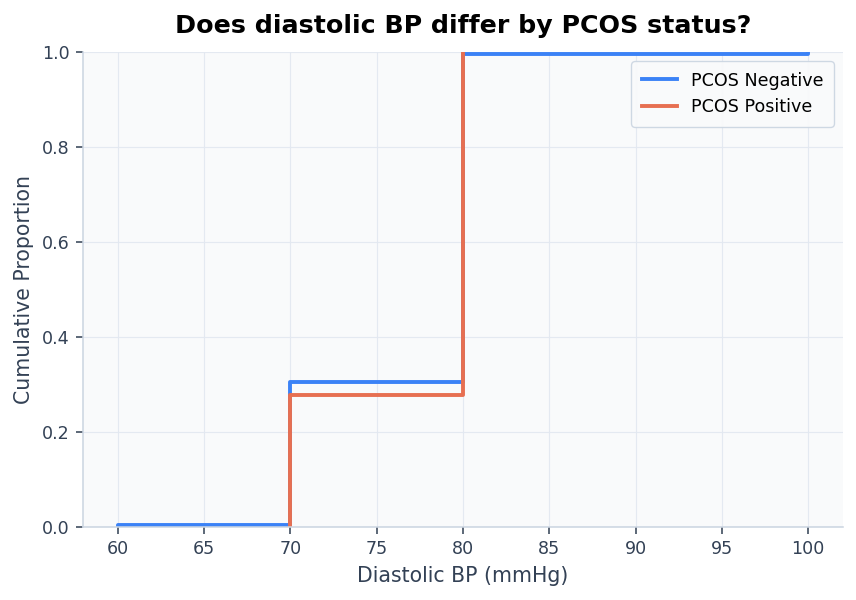

In [16]:
display(grouped_numeric_summary(df, 'diastolic_bp_mmhg'))
plot_numeric_by_target(
    data=df, feature='diastolic_bp_mmhg', ylabel='Diastolic BP (mmHg)',
    title='Does diastolic BP differ by PCOS status?',
    slug='q13_diastolic_bp_mmhg_vs_pcos.png',
    kind='ecdf_hue',
)


### Insight
**Scientific interpretation:** The diastolic ECDF curves are also tightly aligned, with only minimal separation at comparable cumulative levels. This indicates that the two groups occupy almost the same diastolic blood-pressure distribution.

**Simple summary:** Diastolic blood pressure is also almost the same across the groups.

**Why this matters:** This reduces the case for using diastolic pressure as a primary screening feature for PCOS.


### Q14 · Does random blood sugar differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,99.203,96.0,15.504,60.0,225.0
1,PCOS Positive,177,101.137,100.0,23.633,70.0,350.0


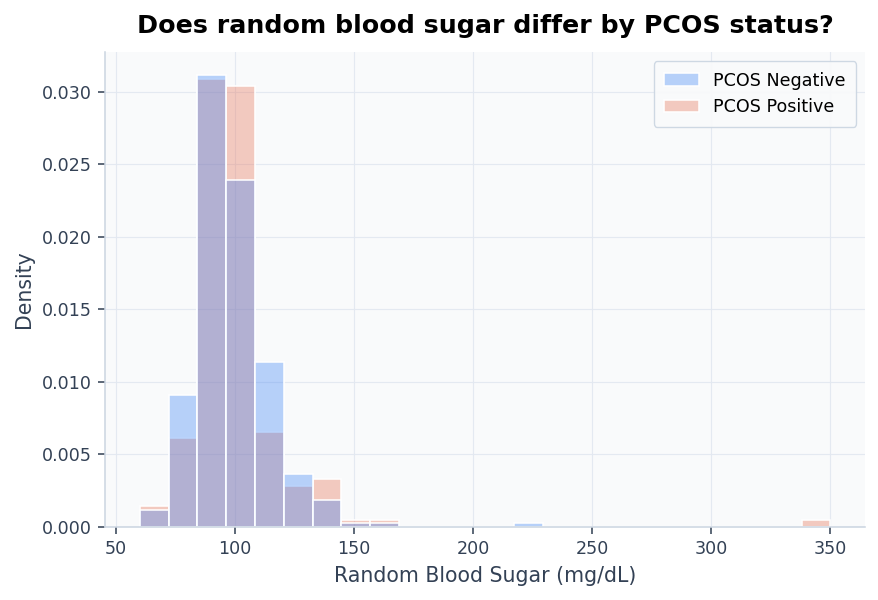

In [17]:
display(grouped_numeric_summary(df, 'rbs_mg_dl'))
plot_numeric_by_target(
    data=df, feature='rbs_mg_dl', ylabel='Random Blood Sugar (mg/dL)',
    title='Does random blood sugar differ by PCOS status?',
    slug='q14_rbs_mg_dl_vs_pcos.png',
    kind='hist_hue',
)


### Insight
**Scientific interpretation:** The random blood-sugar summary shows only a modest increase in the PCOS-positive group, and the histogram reveals considerable overlap with a slightly heavier upper tail among positive participants. The pattern therefore suggests metabolic stress, but not a clean standalone separator.

**Simple summary:** Blood sugar is a little higher in the PCOS-positive group, especially at the upper end, but the groups still overlap a lot.

**Why this matters:** Glycaemic measures may add supportive metabolic information when combined with stronger features such as BMI and symptom burden.


### Section Synthesis
**Cross-chart reading:** Across the continuous variables, the strongest non-invasive shifts are appearing in weight, BMI, the recorded cycle variables, and to a lesser extent random blood sugar, while age, pulse, respiratory rate, haemoglobin, and blood pressure remain heavily overlapping.

**How the findings relate:** This combination suggests that the PCOS-positive phenotype in this cohort is more metabolic and menstrual than haemodynamic.

**Practical interpretation:** A screening-oriented feature set should prioritize body-composition and cycle-pattern variables before reaching for general vital signs.


## 6 · Binary Symptom and Behaviour Features (Q15 – Q21)


### Q15 · Weight Gain Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,83,22.8
1,PCOS Positive,177,121,68.4


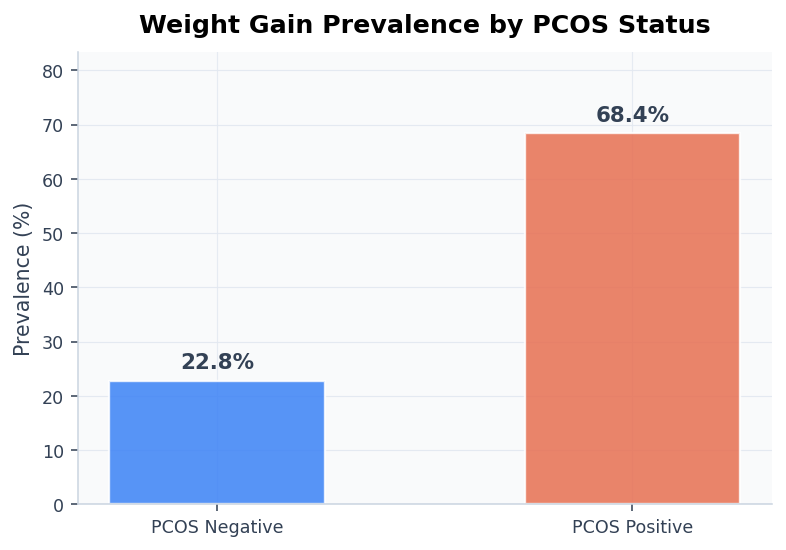

In [18]:
summary_q15 = grouped_binary_prevalence(df, 'weight_gain_y_n')
display(summary_q15)
plot_binary_prevalence(summary_q15, title='Weight Gain Prevalence by PCOS Status', slug='q15_weight_gain_y_n_prevalence.png')


### Insight
**Scientific interpretation:** The prevalence table shows a large gap in reported weight gain between groups, and the bar chart makes that gap one of the clearest non-invasive differences in the notebook. This looks like a broad cohort pattern rather than a marginal effect.

**Simple summary:** Weight gain is much more common in the PCOS-positive group.

**Why this matters:** Weight gain is easy to ask about and appears to carry real screening value in this cohort.


### Q16 · Hair Growth Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,47,12.9
1,PCOS Positive,177,101,57.1


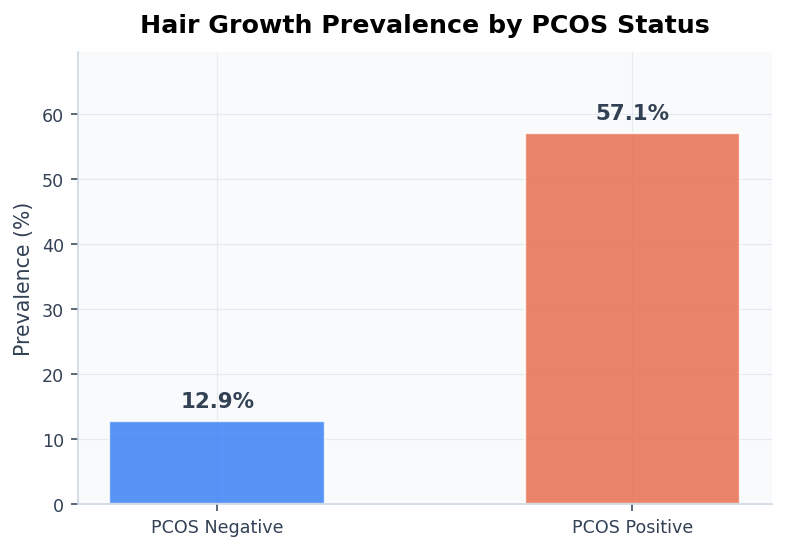

In [19]:
summary_q16 = grouped_binary_prevalence(df, 'hair_growth_y_n')
display(summary_q16)
plot_binary_prevalence(summary_q16, title='Hair Growth Prevalence by PCOS Status', slug='q16_hair_growth_y_n_prevalence.png')


### Insight
**Scientific interpretation:** Hair growth prevalence rises sharply in the PCOS-positive group, and the bar chart shows a strong gap rather than a subtle increase. This is consistent with excess hair growth behaving as an androgen-linked symptom.

**Simple summary:** Excess hair growth is much more common among PCOS-positive participants.

**Why this matters:** Visible androgenic symptoms are valuable because they can strengthen non-invasive screening without laboratory testing.


### Q17 · Skin Darkening Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,56,15.4
1,PCOS Positive,177,110,62.1


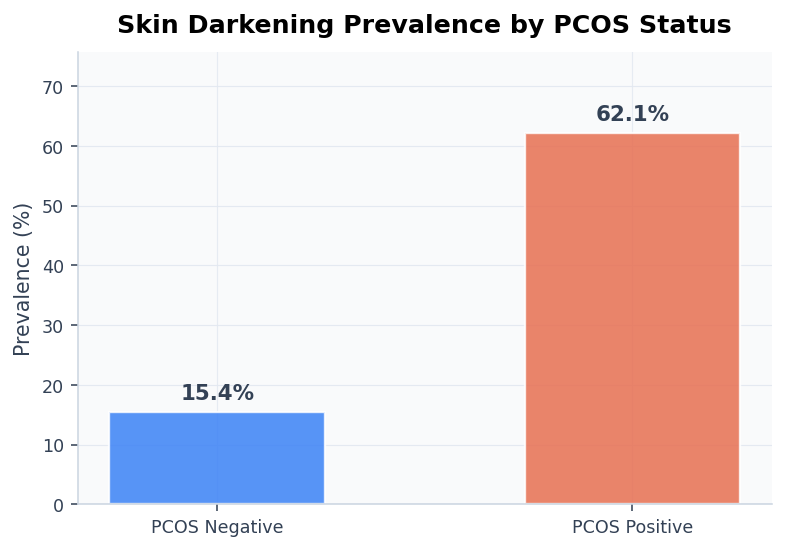

In [20]:
summary_q17 = grouped_binary_prevalence(df, 'skin_darkening_y_n')
display(summary_q17)
plot_binary_prevalence(summary_q17, title='Skin Darkening Prevalence by PCOS Status', slug='q17_skin_darkening_y_n_prevalence.png')


### Insight
**Scientific interpretation:** Skin darkening shows one of the largest prevalence differences in the entire symptom section, with a very clear visual separation between groups. That pattern is consistent with skin darkening acting as a visible marker of metabolic strain in this cohort.

**Simple summary:** Skin darkening is far more common in the PCOS-positive group.

**Why this matters:** This makes skin darkening a high-value symptom feature for later screening and interpretation.


### Q18 · Hair Loss Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,143,39.3
1,PCOS Positive,177,102,57.6


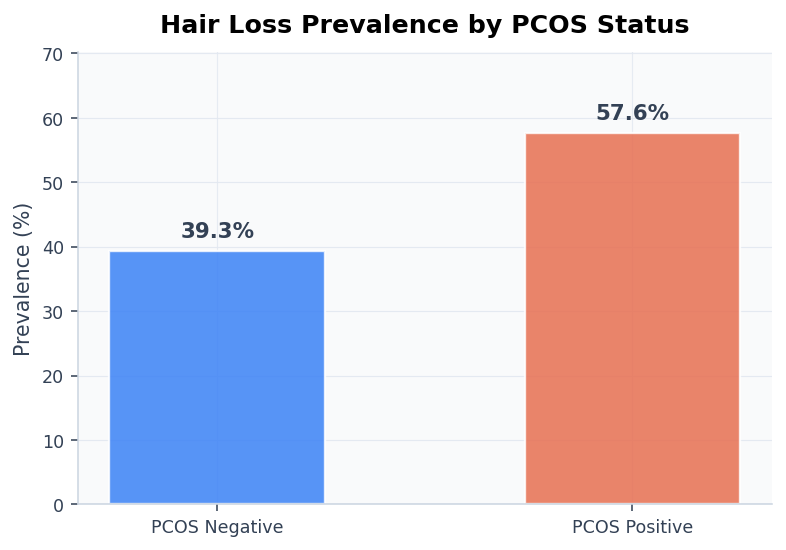

In [21]:
summary_q18 = grouped_binary_prevalence(df, 'hair_loss_y_n')
display(summary_q18)
plot_binary_prevalence(summary_q18, title='Hair Loss Prevalence by PCOS Status', slug='q18_hair_loss_y_n_prevalence.png')


### Insight
**Scientific interpretation:** Hair loss is more prevalent in the PCOS-positive group, but the gap is smaller than for hair growth or skin darkening. The bar chart therefore supports hair loss as a relevant symptom, though not one of the strongest separators.

**Simple summary:** Hair loss matters, but it is not as strong as the top symptom signals.

**Why this matters:** It may still contribute useful incremental information when combined with stronger visible symptoms.


### Q19 · Pimples Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,142,39.0
1,PCOS Positive,177,123,69.5


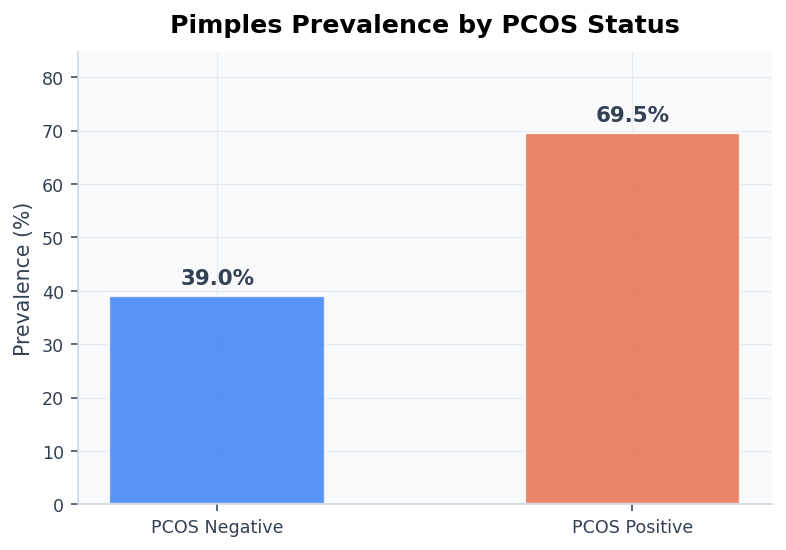

In [22]:
summary_q19 = grouped_binary_prevalence(df, 'pimples_y_n')
display(summary_q19)
plot_binary_prevalence(summary_q19, title='Pimples Prevalence by PCOS Status', slug='q19_pimples_y_n_prevalence.png')


### Insight
**Scientific interpretation:** Pimples prevalence increases clearly in the PCOS-positive group, and the bar chart suggests a real androgen-related signal rather than random fluctuation. The separation is meaningful even though it is not as extreme as skin darkening or weight gain.

**Simple summary:** Pimples are more common in the PCOS-positive group.

**Why this matters:** Acne-related symptoms can add practical screening value, especially when interpreted alongside other androgenic features.


### Q20 · Fast Food Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,140,38.5
1,PCOS Positive,177,139,78.5


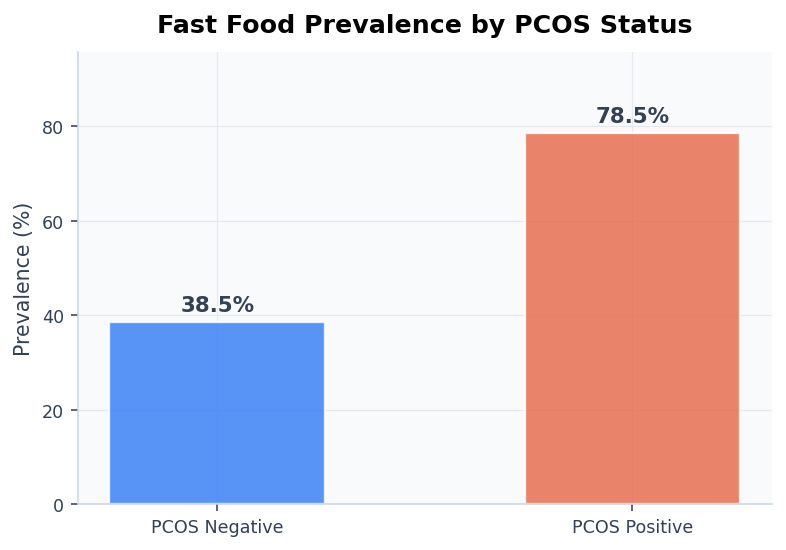

In [23]:
summary_q20 = grouped_binary_prevalence(df, 'fast_food_y_n')
display(summary_q20)
plot_binary_prevalence(summary_q20, title='Fast Food Prevalence by PCOS Status', slug='q20_fast_food_y_n_prevalence.png')


### Insight
**Scientific interpretation:** Fast-food prevalence is visibly higher in the PCOS-positive group, producing a larger gap than many routine lifestyle variables. Even so, the interpretation should remain cautious because diet questions can reflect broader behavioural, social, and reporting differences.

**Simple summary:** Fast-food intake shows a noticeable group difference, but it may not be a direct PCOS marker.

**Why this matters:** This feature may help as background lifestyle information, yet it should not be treated as a causal or syndrome-specific signal without further evidence.


### Q21 · Regular Exercise Prevalence by PCOS Status


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,364,83,22.8
1,PCOS Positive,177,51,28.8


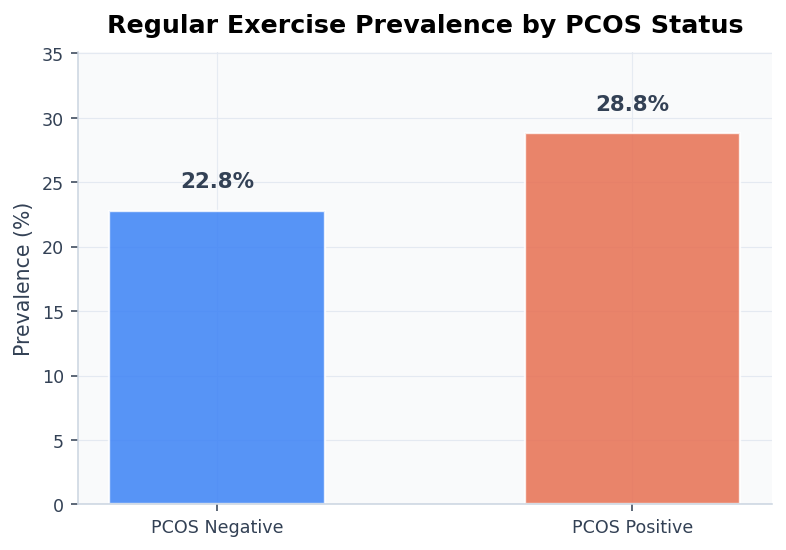

In [24]:
summary_q21 = grouped_binary_prevalence(df, 'regular_exercise_y_n')
display(summary_q21)
plot_binary_prevalence(summary_q21, title='Regular Exercise Prevalence by PCOS Status', slug='q21_regular_exercise_y_n_prevalence.png')


### Insight
**Scientific interpretation:** Regular exercise shows only a small difference between groups, and the bar heights remain relatively close compared with the stronger symptom features. That makes exercise a weak separator in this dataset.

**Simple summary:** Exercise does not distinguish the groups very much here.

**Why this matters:** Regular exercise may still matter clinically, but it looks more like a background lifestyle variable than a primary PCOS screening feature.


### Section Synthesis
**Cross-chart reading:** Weight gain, hair growth, skin darkening, and pimples move together as the clearest observable symptom signals. Hair loss is present but less specific, while regular exercise contributes very little separation and fast food likely captures broader behaviour rather than direct biology.

**How the findings relate:** The symptom cluster complements the BMI and cycle findings from the previous section and points toward an androgenic-metabolic phenotype rather than a single isolated complaint.

**Practical interpretation:** These easy-to-report features are strong candidates for non-invasive modelling, although diet and exercise variables should be treated as background rather than causal markers.


## 7 · Reproductive and Ovarian Structure Features (Q22 – Q28)


### Q22 · Do left-ovary follicle counts differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,4.352,4.0,2.814,0,15
1,PCOS Positive,177,9.785,10.0,4.309,1,22


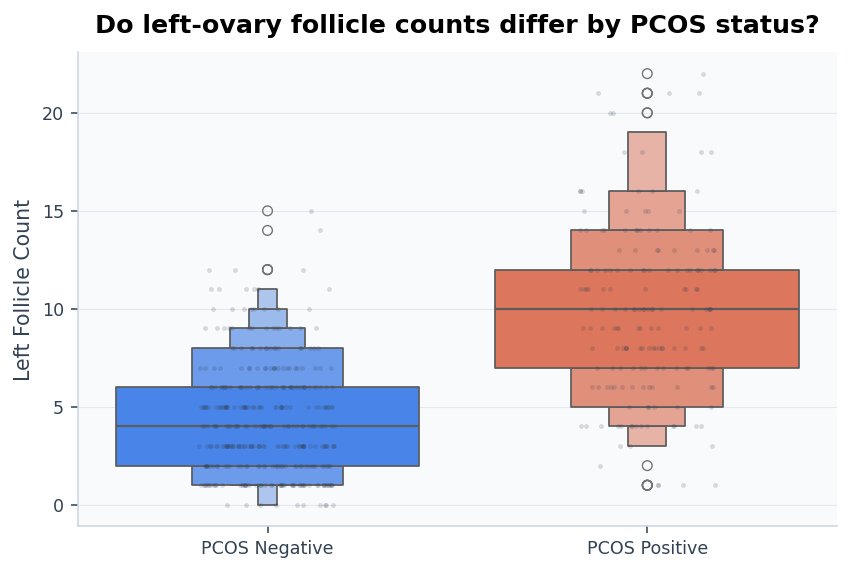

In [25]:
display(grouped_numeric_summary(df, 'follicle_no_left'))
plot_numeric_by_target(
    data=df, feature='follicle_no_left', ylabel='Left Follicle Count',
    title='Do left-ovary follicle counts differ by PCOS status?',
    slug='q22_follicle_no_left_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** Left-ovary follicle counts are much higher in the PCOS-positive group, and the boxen plot shows the upward shift across the distribution rather than only at the extremes. This is a strong ovarian morphology signal.

**Simple summary:** PCOS-positive participants tend to have many more follicles on the left ovary.

**Why this matters:** Follicle count is one of the clearest reproductive features in the notebook and helps anchor the biological interpretation of the syndrome.


### Q23 · Do right-ovary follicle counts differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,4.637,4.0,2.926,0,16
1,PCOS Positive,177,10.763,11.0,4.166,1,20


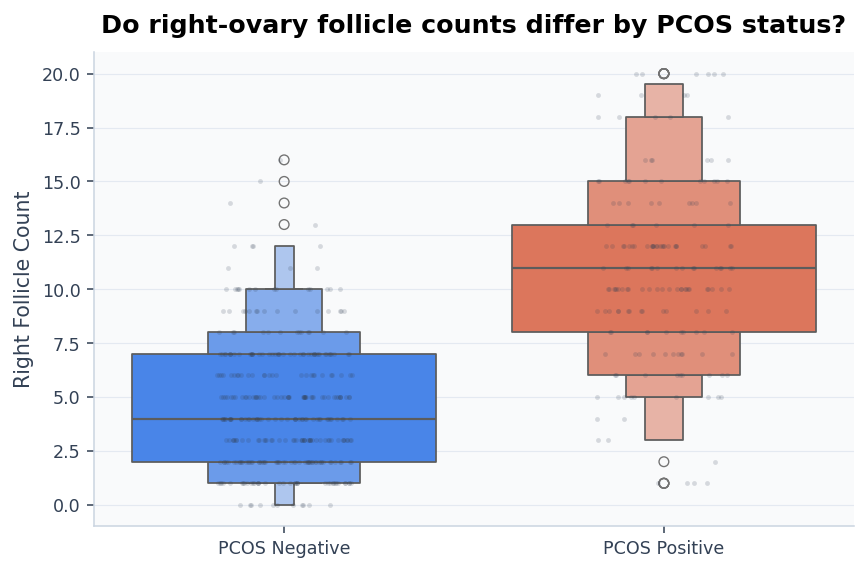

In [26]:
display(grouped_numeric_summary(df, 'follicle_no_right'))
plot_numeric_by_target(
    data=df, feature='follicle_no_right', ylabel='Right Follicle Count',
    title='Do right-ovary follicle counts differ by PCOS status?',
    slug='q23_follicle_no_right_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** Right-ovary follicle counts mirror the left-sided pattern, again with a clear upward shift in the PCOS-positive group. The consistency across ovaries strengthens the ovarian-morphology interpretation.

**Simple summary:** The right ovary shows the same higher follicle burden pattern as the left.

**Why this matters:** A bilateral pattern is more convincing than a one-sided result and supports follicle burden as a robust PCOS feature.


### Q24 · Do average follicle sizes differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,15.226,15.0,3.406,0.00,24.0
1,PCOS Positive,177,15.916,16.0,3.089,0.17,23.0


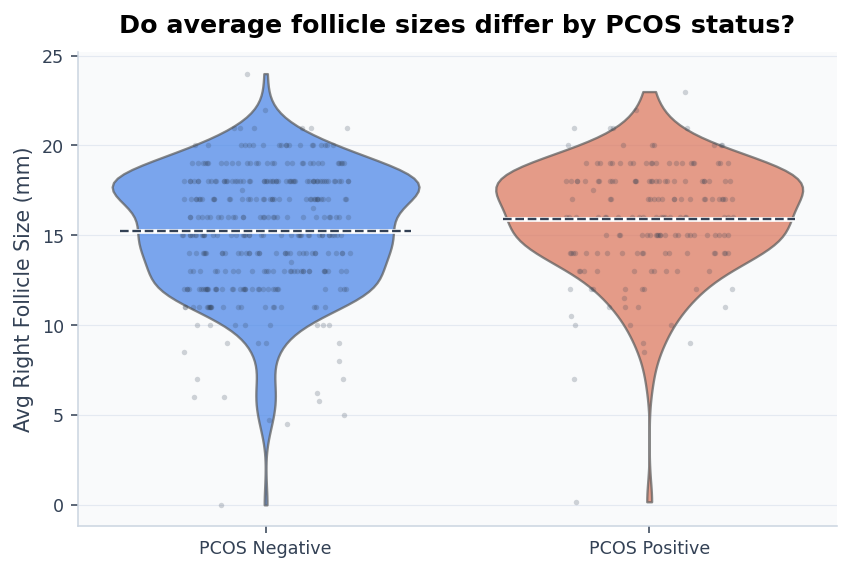

In [27]:
display(grouped_numeric_summary(df, 'avg_follicle_size_right_mm'))
plot_numeric_by_target(
    data=df, feature='avg_follicle_size_right_mm', ylabel='Avg Right Follicle Size (mm)',
    title='Do average follicle sizes differ by PCOS status?',
    slug='q24_avg_follicle_size_right_mm_vs_pcos.png',
    kind='violin_strip',
)


### Insight
**Scientific interpretation:** Average follicle size changes less dramatically than follicle count, and the violin distributions overlap more than the count distributions do. This suggests that number of follicles is more informative than average follicle size in this cohort.

**Simple summary:** Follicle count matters more than follicle size here.

**Why this matters:** If ovarian variables are triaged later, count should receive more emphasis than average size.


### Q25 · Does endometrium thickness differ by PCOS status?


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,8.362,8.35,2.172,2.5,18.0
1,PCOS Positive,177,8.807,8.90,1.924,4.5,15.0


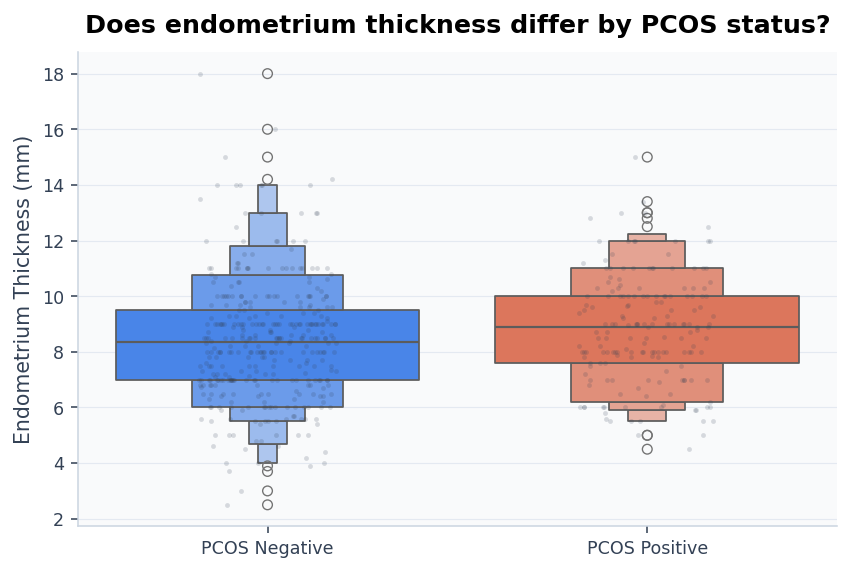

In [28]:
display(grouped_numeric_summary(df, 'endometrium_mm'))
plot_numeric_by_target(
    data=df, feature='endometrium_mm', ylabel='Endometrium Thickness (mm)',
    title='Does endometrium thickness differ by PCOS status?',
    slug='q25_endometrium_mm_vs_pcos.png',
    kind='boxen_strip',
)


### Insight
**Scientific interpretation:** Endometrium thickness shows only a modest upward shift in the PCOS-positive group, with noticeable overlap between distributions. The feature is therefore providing supplementary reproductive context rather than dominating the separation.

**Simple summary:** Endometrium thickness changes a bit, but not as strongly as follicle count.

**Why this matters:** It may still enrich specialist interpretation, yet it is not the main reproductive signal in this notebook.


### Q26 · Are follicle counts higher among participants with skin darkening?


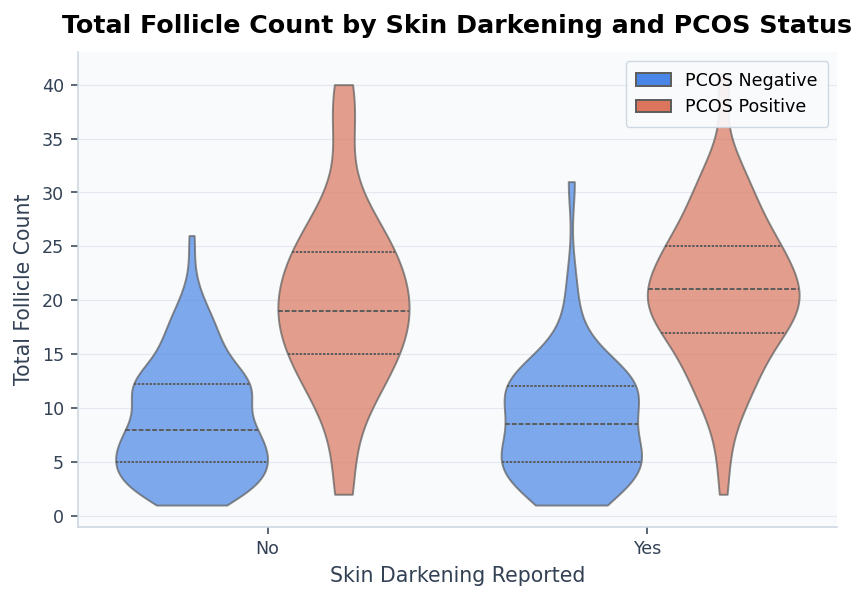

In [29]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
sns.violinplot(data=df, x='skin_darkening_y_n_label', y='total_follicle_count',
               hue='pcos_label', order=['No','Yes'],
               hue_order=PCOS_LABEL_ORDER, palette=PCOS_LABEL_PALETTE,
               cut=0, inner='quartile', linewidth=1.0, ax=ax, saturation=0.84)
for coll in ax.collections:
    coll.set_alpha(0.70)
ax.set_title('Total Follicle Count by Skin Darkening and PCOS Status')
ax.set_xlabel('Skin Darkening Reported')
ax.set_ylabel('Total Follicle Count')
finish(ax)
save_figure(fig, 'q26_skin_darkening_y_n_follicle.png')
plt.show()


### Insight
**Scientific interpretation:** The split violins suggest that participants reporting skin darkening tend to occupy higher follicle-count distributions, and that upward shift is most visible once PCOS status is layered in. This is an association rather than a causal claim, but it links a visible metabolic sign to ovarian morphology.

**Simple summary:** People with skin darkening tend to show heavier follicle burden, especially inside the PCOS-positive group.

**Why this matters:** This kind of cross-feature alignment is valuable because it connects an observable symptom with a biologically relevant ovarian pattern.


### Q27 · Are follicle counts higher among participants with hair growth?


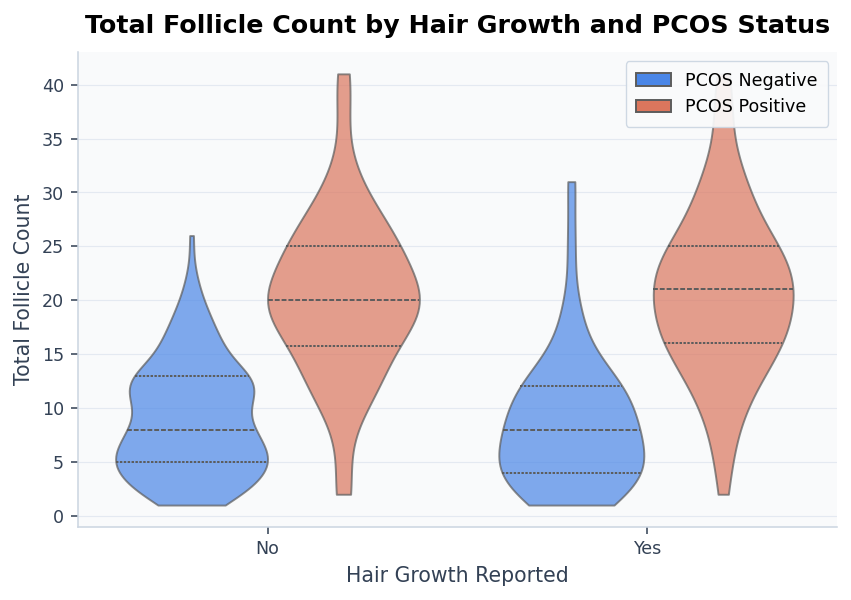

In [30]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
sns.violinplot(data=df, x='hair_growth_y_n_label', y='total_follicle_count',
               hue='pcos_label', order=['No','Yes'],
               hue_order=PCOS_LABEL_ORDER, palette=PCOS_LABEL_PALETTE,
               cut=0, inner='quartile', linewidth=1.0, ax=ax, saturation=0.84)
for coll in ax.collections:
    coll.set_alpha(0.70)
ax.set_title('Total Follicle Count by Hair Growth and PCOS Status')
ax.set_xlabel('Hair Growth Reported')
ax.set_ylabel('Total Follicle Count')
finish(ax)
save_figure(fig, 'q27_hair_growth_y_n_follicle.png')
plt.show()


### Insight
**Scientific interpretation:** The follicle-count distributions also shift upward among participants reporting hair growth, and the coloured violins suggest that the pattern is most pronounced in the PCOS-positive subgroup. Hair growth is therefore aligning with a deeper ovarian phenotype rather than behaving as a purely cosmetic complaint.

**Simple summary:** Participants with excess hair growth tend to have higher follicle counts.

**Why this matters:** That alignment strengthens the case for hair growth as a meaningful screening symptom, not just a background report.


### Q28 · Are follicle counts higher among participants with weight gain?


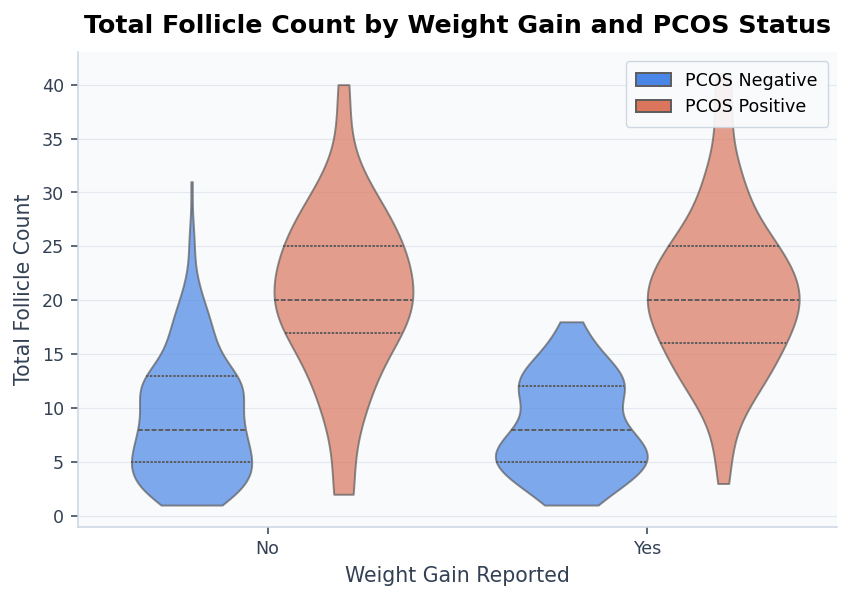

In [31]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
sns.violinplot(data=df, x='weight_gain_y_n_label', y='total_follicle_count',
               hue='pcos_label', order=['No','Yes'],
               hue_order=PCOS_LABEL_ORDER, palette=PCOS_LABEL_PALETTE,
               cut=0, inner='quartile', linewidth=1.0, ax=ax, saturation=0.84)
for coll in ax.collections:
    coll.set_alpha(0.70)
ax.set_title('Total Follicle Count by Weight Gain and PCOS Status')
ax.set_xlabel('Weight Gain Reported')
ax.set_ylabel('Total Follicle Count')
finish(ax)
save_figure(fig, 'q28_weight_gain_y_n_follicle.png')
plt.show()


### Insight
**Scientific interpretation:** Participants reporting weight gain tend to show higher follicle-count distributions than those who do not, and the split violins again suggest that the heavier ovarian burden is clustering in the positive class. This points to a combined metabolic and reproductive pattern.

**Simple summary:** Weight gain and higher follicle burden appear to travel together.

**Why this matters:** Cross-feature clustering like this is useful because it suggests the syndrome is being expressed through connected processes rather than isolated variables.


## 8 · Joint Shift and Redundancy Analysis (Q29 – Q33)


### Q29 · BMI and waist-hip ratio jointly shifted?


bmi               waist_hip_ratio              
                 mean median    std            mean median    std
pcos_label                                                       
PCOS Negative  23.747   23.6  3.759           0.891  0.895  0.046
PCOS Positive  25.471   25.1  4.396           0.893  0.897  0.046

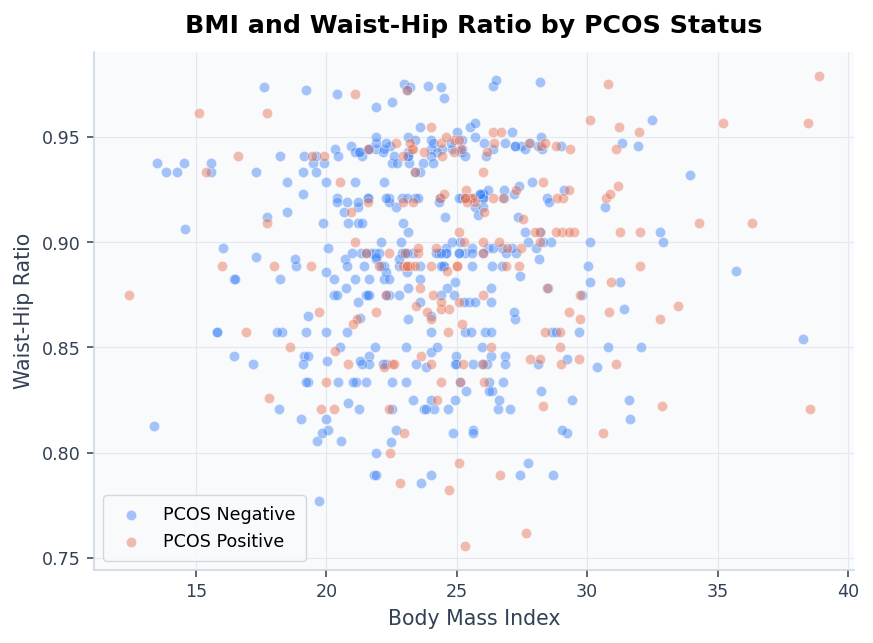

In [32]:
display(df.groupby('pcos_label')[['bmi','waist_hip_ratio']]
         .agg(['mean','median','std']).round(3))

fig, ax = plt.subplots(figsize=(7.0, 4.8))
for label in PCOS_LABEL_ORDER:
    sub = df[df['pcos_label']==label]
    ax.scatter(sub['bmi'], sub['waist_hip_ratio'],
               color=PCOS_LABEL_PALETTE[label], alpha=0.45, s=28,
               edgecolors='white', linewidth=0.4, label=label)
ax.set_xlabel('Body Mass Index')
ax.set_ylabel('Waist-Hip Ratio')
ax.set_title('BMI and Waist-Hip Ratio by PCOS Status')
ax.legend(); finish(ax, 'both')
save_figure(fig, 'q29_bmi_waist_hip_scatter.png')
plt.show()


### Insight
**Scientific interpretation:** The joint scatter shows that the PCOS-positive cloud separates more along the BMI axis than along the waist-hip-ratio axis. The main group shift is therefore horizontal rather than strongly vertical, which is consistent with BMI carrying the stronger independent signal.

**Simple summary:** BMI is doing more of the separating work than waist-hip ratio in this paired view.

**Why this matters:** When both features are available, BMI appears to be the more informative primary anthropometric measure.


### Q30 · Blood pressure and random blood sugar jointly shifted?


systolic_bp_mmhg               diastolic_bp_mmhg                \
                          mean median    std              mean median    std   
pcos_label                                                                     
PCOS Negative          114.890  110.0  6.052            76.978   80.0  4.832   
PCOS Positive          114.746  110.0  5.648            77.232   80.0  4.487   

              rbs_mg_dl                 
                   mean median     std  
pcos_label                              
PCOS Negative    99.203   96.0  15.504  
PCOS Positive   101.137  100.0  23.633

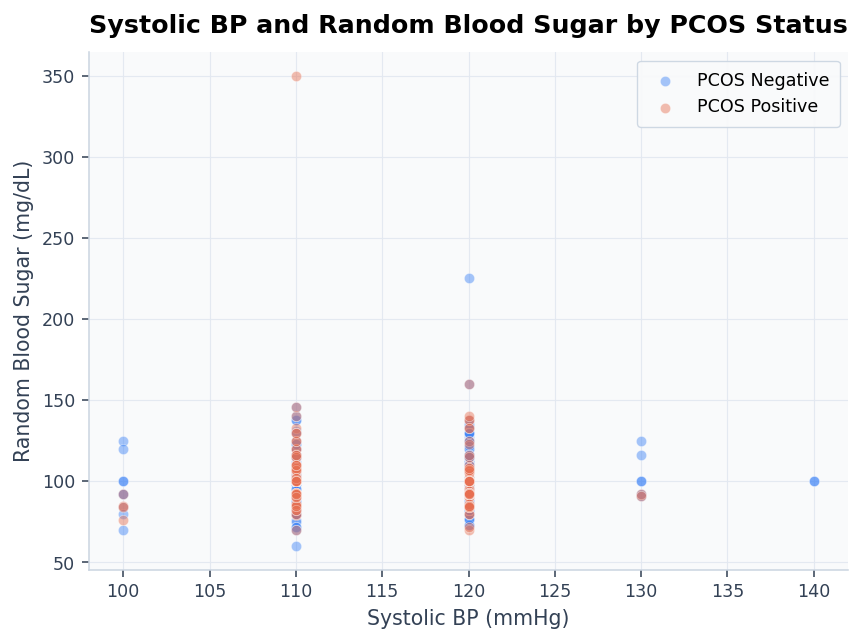

In [33]:
display(df.groupby('pcos_label')[['systolic_bp_mmhg','diastolic_bp_mmhg','rbs_mg_dl']]
         .agg(['mean','median','std']).round(3))

fig, ax = plt.subplots(figsize=(7.0, 4.8))
for label in PCOS_LABEL_ORDER:
    sub = df[df['pcos_label']==label]
    ax.scatter(sub['systolic_bp_mmhg'], sub['rbs_mg_dl'],
               color=PCOS_LABEL_PALETTE[label], alpha=0.45, s=28,
               edgecolors='white', linewidth=0.4, label=label)
ax.set_xlabel('Systolic BP (mmHg)')
ax.set_ylabel('Random Blood Sugar (mg/dL)')
ax.set_title('Systolic BP and Random Blood Sugar by PCOS Status')
ax.legend(); finish(ax, 'both')
save_figure(fig, 'q30_bp_rbs_scatter.png')
plt.show()


### Insight
**Scientific interpretation:** The blood-pressure and blood-sugar scatter shows heavy overlap in blood pressure, while the PCOS-positive cloud extends a little further into higher random blood-sugar values. The joint pattern therefore looks metabolically suggestive rather than haemodynamically distinct.

**Simple summary:** Blood pressure looks similar between groups, but blood sugar stretches a bit higher in the PCOS-positive group.

**Why this matters:** This supports using glycaemic context as a secondary metabolic feature rather than relying on blood pressure as a main screening signal.


### Section Synthesis
**Cross-chart reading:** Ovarian burden is shifting far more strongly than follicle size, symptom-positive subgroups tend to carry higher follicle counts, BMI separates more clearly than waist-hip ratio, and blood sugar adds only a modest metabolic extension beyond blood pressure.

**How the findings relate:** The ovarian, anthropometric, and visible-symptom signals are telling a consistent story of clustered reproductive and metabolic disturbance.

**Practical interpretation:** Later models should likely gain more from combining follicle burden with strong non-invasive features than from emphasizing weak haemodynamic variables.


### Q31 · Spearman correlations with PCOS status


,feature,spearman_r
17,total_follicle_count,0.6428
13,follicle_no_right,0.6280
12,follicle_no_left,0.5807
18,non_invasive_burden_score,0.5236
8,cycle_regularity_code,0.4012
2,bmi,0.1962
1,weight_kg,0.1950
4,pulse_rate_bpm,0.1204
16,endometrium_mm,0.1183
14,avg_follicle_size_left_mm,0.1119


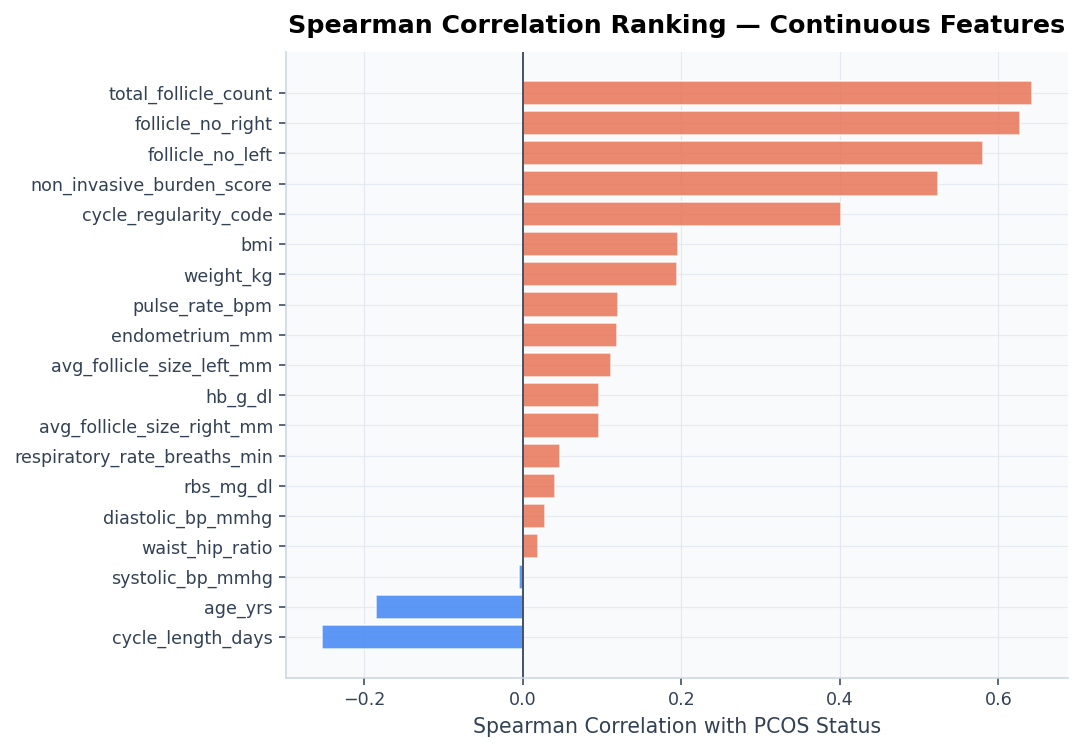

In [34]:
cont_feats = [
    'age_yrs','weight_kg','bmi','waist_hip_ratio','pulse_rate_bpm',
    'respiratory_rate_breaths_min','hb_g_dl','cycle_length_days',
    'cycle_regularity_code','systolic_bp_mmhg','diastolic_bp_mmhg','rbs_mg_dl',
    'follicle_no_left','follicle_no_right',
    'avg_follicle_size_left_mm','avg_follicle_size_right_mm','endometrium_mm',
    'total_follicle_count','non_invasive_burden_score',
]
corrs = []
for f in cont_feats:
    r, _ = stats.spearmanr(df[f].fillna(df[f].median()), df['pcos_y_n'])
    corrs.append({'feature': f, 'spearman_r': round(r, 4)})
corr_df = pd.DataFrame(corrs).sort_values('spearman_r', ascending=False)
display(corr_df)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
colors = [PALETTE['pos'] if r > 0 else PALETTE['neg'] for r in corr_df['spearman_r']]
ax.barh(corr_df['feature'], corr_df['spearman_r'], color=colors,
        alpha=0.82, edgecolor='white', linewidth=0.8)
ax.axvline(0, color=PALETTE['slate'], linewidth=0.9)
ax.set_xlabel('Spearman Correlation with PCOS Status')
ax.set_title('Spearman Correlation Ranking — Continuous Features')
ax.invert_yaxis(); finish(ax, 'x')
save_figure(fig, 'q31_spearman_ranking.png')
plt.show()


### Insight
**Scientific interpretation:** The correlation ranking shows that monotonic alignment with PCOS is strongest for ovarian burden and adiposity-linked variables, while general vital signs sit closer to zero. The bar chart is helping separate genuinely informative continuous features from background physiology.

**Simple summary:** Ovarian counts and body-composition features relate to PCOS much more strongly than pulse, breathing rate, or blood pressure.

**Why this matters:** This is useful for feature triage because it highlights which continuous variables deserve priority in later models.


### Q32 · Symptom-to-symptom Spearman correlation


,weight_gain_y_n,hair_growth_y_n,skin_darkening_y_n,hair_loss_y_n,pimples_y_n,fast_food_y_n,regular_exercise_y_n
weight_gain_y_n,1.000,0.301,0.351,0.250,0.252,0.372,-0.040
hair_growth_y_n,0.301,1.000,0.374,0.208,0.153,0.296,0.013
skin_darkening_y_n,0.351,0.374,1.000,0.127,0.166,0.340,0.110
hair_loss_y_n,0.250,0.208,0.127,1.000,0.245,0.280,-0.006
pimples_y_n,0.252,0.153,0.166,0.245,1.000,0.291,0.089
fast_food_y_n,0.372,0.296,0.340,0.280,0.291,1.000,0.068
regular_exercise_y_n,-0.040,0.013,0.110,-0.006,0.089,0.068,1.000


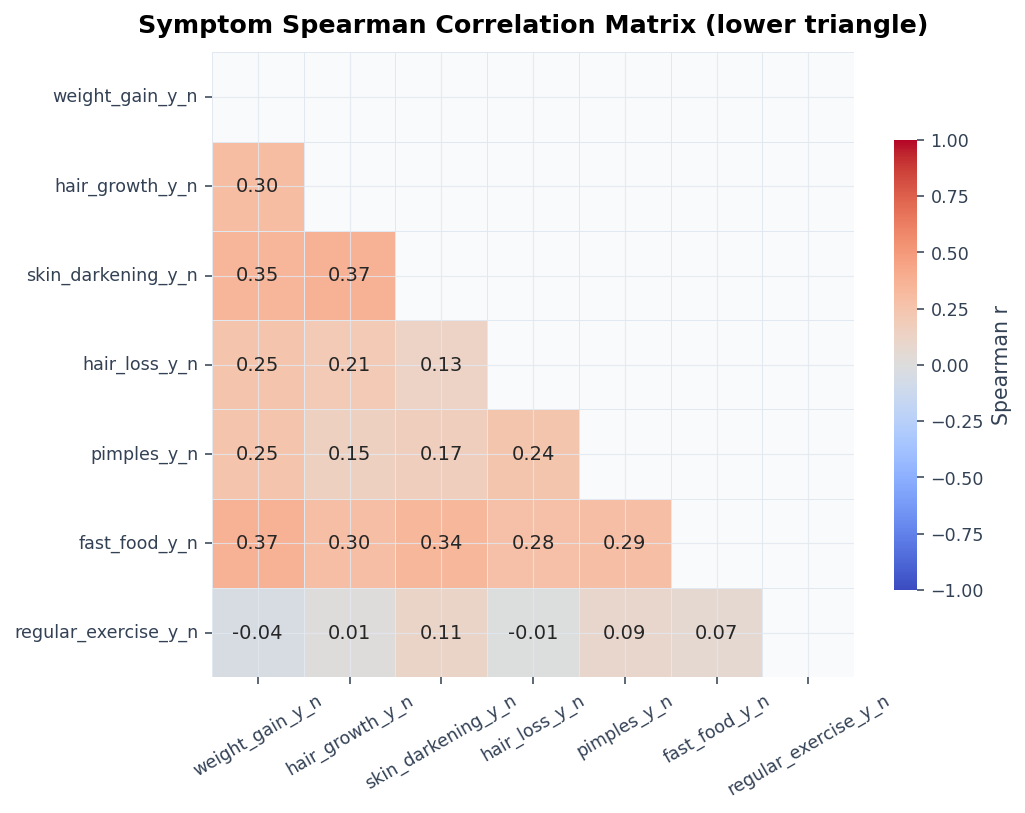

In [35]:
sym_feats = ['weight_gain_y_n','hair_growth_y_n','skin_darkening_y_n',
             'hair_loss_y_n','pimples_y_n','fast_food_y_n','regular_exercise_y_n']
corr_mat = df[sym_feats].corr(method='spearman').round(3)
display(corr_mat)

fig, ax = plt.subplots(figsize=(7.4, 5.8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#e2e8f0',
            cbar_kws={'label':'Spearman r', 'shrink':0.72}, ax=ax)
ax.set_title('Symptom Spearman Correlation Matrix (lower triangle)')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
save_figure(fig, 'q32_symptom_spearman_heatmap.png')
plt.show()


### Insight
**Scientific interpretation:** The symptom correlation heatmap shows that several visible or behaviour-linked variables move together rather than independently. Warmer cells indicate overlapping signal, meaning some features may be partially redundant even if each one is individually associated with PCOS.

**Simple summary:** Some symptoms are telling similar stories instead of providing completely new information.

**Why this matters:** Later modelling should avoid over-rewarding duplicated signal and should test whether correlated symptoms can be combined or pruned.


### Q33 · Pimples x skin darkening overlap


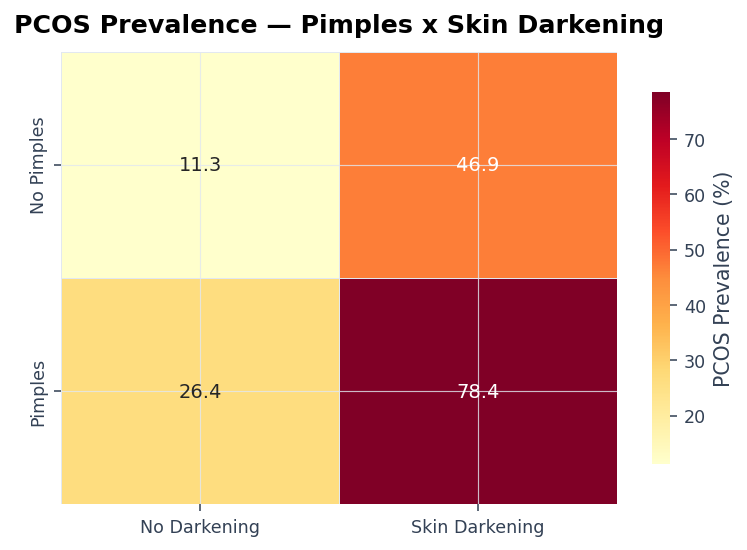

In [36]:
summary_q33 = (df.groupby(['pimples_y_n','skin_darkening_y_n'])['pcos_y_n']
               .agg(['count','mean'])
               .rename(columns={'count':'n','mean':'pcos_prevalence'})
               .reset_index())
summary_q33['pcos_pct'] = (summary_q33['pcos_prevalence']*100).round(1)
heatmap_q33 = summary_q33.pivot(index='pimples_y_n',
                                columns='skin_darkening_y_n',
                                values='pcos_pct')
heatmap_q33.index   = heatmap_q33.index.map({0:'No Pimples', 1:'Pimples'})
heatmap_q33.columns = heatmap_q33.columns.map({0:'No Darkening', 1:'Skin Darkening'})

fig, ax = plt.subplots(figsize=(6.4, 4.2))
sns.heatmap(heatmap_q33, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, linecolor='#e2e8f0',
            cbar_kws={'label':'PCOS Prevalence (%)', 'shrink':0.82}, ax=ax)
ax.set_title('PCOS Prevalence — Pimples x Skin Darkening')
ax.set_xlabel(''); ax.set_ylabel('')
save_figure(fig, 'q33_pimples_skin_darkening_overlap.png')
plt.show()


### Insight
**Scientific interpretation:** The overlap heatmap suggests that the co-occurrence of pimples and skin darkening is more concentrated in the PCOS-positive group than a neutral pattern would imply. The pair therefore looks more informative together than as two unrelated complaints.

**Simple summary:** Having pimples and skin darkening together looks more characteristic of the PCOS-positive group than the background pattern would suggest.

**Why this matters:** Symptom combinations may be more informative than single yes-no indicators, which supports later feature engineering.


## 9 · Derived Feature Analysis (Q34 – Q36)


### Q34 · BMI category distribution by PCOS status


pcos_label,PCOS Negative,PCOS Positive
bmi_category,,
Underweight,7.1,5.6
Normal,56.3,42.4
Overweight,31.3,38.4
Obese,5.2,13.6


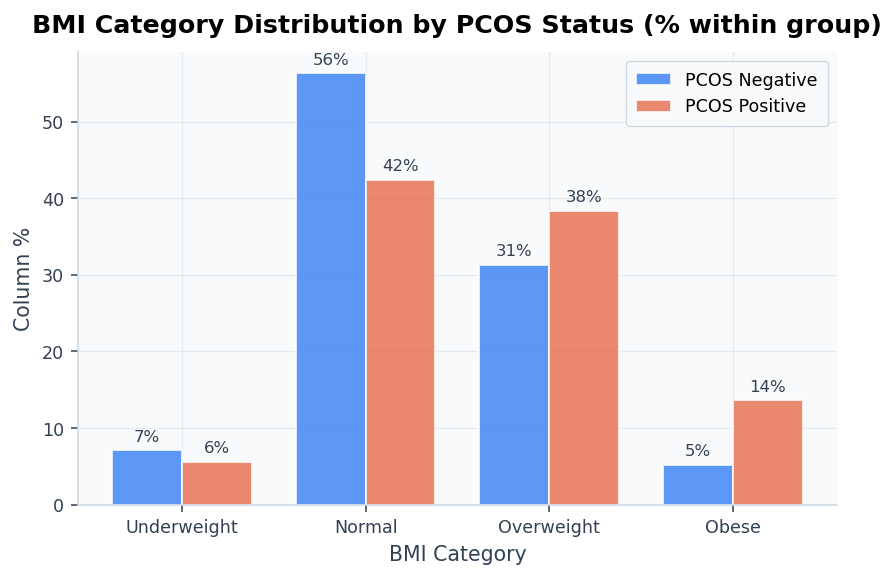

In [37]:
bmi_cat_order = ['Underweight','Normal','Overweight','Obese']
summary_q34 = (pd.crosstab(df['bmi_category'], df['pcos_label'], normalize='columns')
               .mul(100).round(1))
display(summary_q34)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
width = 0.38
x = np.arange(len(bmi_cat_order))
for i, (label, color) in enumerate(PCOS_LABEL_PALETTE.items()):
    vals = [summary_q34.loc[cat, label] if cat in summary_q34.index else 0
            for cat in bmi_cat_order]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width=width, color=color,
                  alpha=0.82, edgecolor='white', linewidth=1.0, label=label)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f'{v:.0f}%', ha='center', va='bottom',
                fontsize=8.5, color=PALETTE['slate'])
ax.set_xticks(x); ax.set_xticklabels(bmi_cat_order)
ax.set_xlabel('BMI Category'); ax.set_ylabel('Column %')
ax.set_title('BMI Category Distribution by PCOS Status (% within group)')
ax.legend(); finish(ax)
save_figure(fig, 'q34_bmi_category_by_pcos.png')
plt.show()


### Insight
**Scientific interpretation:** The category chart shows the PCOS-positive group accumulating more heavily in the overweight and obese bands, while the negative group retains more mass in the normal range. This means the continuous BMI shift remains visible after categorisation.

**Simple summary:** PCOS-positive participants are more concentrated in higher BMI categories.

**Why this matters:** BMI may be useful both as a continuous value and as a simpler engineered category for screening tools or explainable models.


### Q35 · Non-invasive burden score by PCOS status


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,2.819,3.0,1.559,0,8
1,PCOS Positive,177,5.175,6.0,1.974,0,8


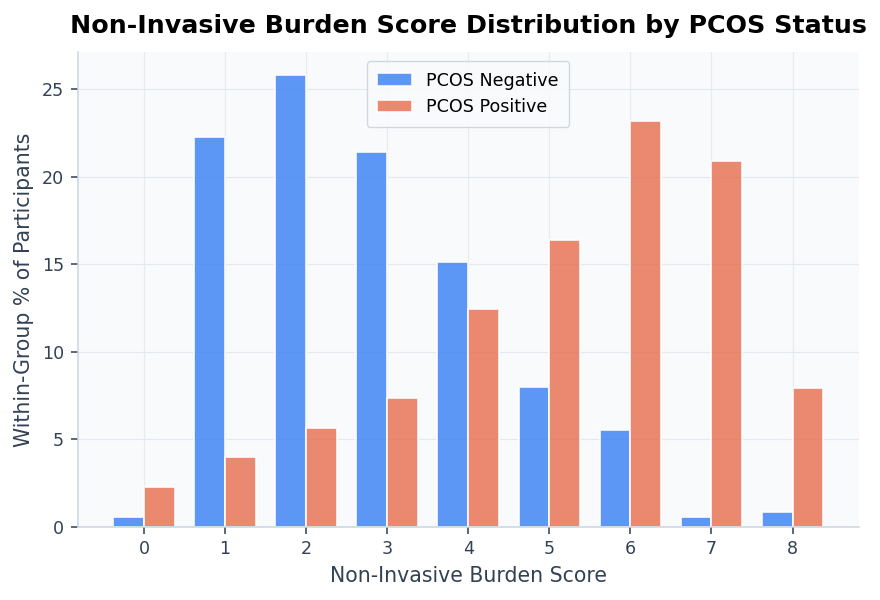

In [38]:
display(grouped_numeric_summary(df, 'non_invasive_burden_score'))

score_range = sorted(df['non_invasive_burden_score'].dropna().unique())
width = 0.38
x = np.arange(len(score_range))

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for i, (label, color) in enumerate(PCOS_LABEL_PALETTE.items()):
    sub = df[df['pcos_label']==label]
    density = [(sub['non_invasive_burden_score']==s).mean()*100 for s in score_range]
    offset = (i - 0.5) * width
    ax.bar(x + offset, density, width=width, color=color,
           alpha=0.82, edgecolor='white', linewidth=1.0, label=label)
ax.set_xticks(x); ax.set_xticklabels([int(s) for s in score_range])
ax.set_xlabel('Non-Invasive Burden Score')
ax.set_ylabel('Within-Group % of Participants')
ax.set_title('Non-Invasive Burden Score Distribution by PCOS Status')
ax.legend(); finish(ax)
save_figure(fig, 'q35_burden_score_by_pcos.png')
plt.show()


### Insight
**Scientific interpretation:** The burden-score distribution places more of the PCOS-positive group at higher symptom-count levels, while the negative group is concentrated at lower scores. This shows that accumulation of routine non-invasive signals is more informative than treating each symptom as fully isolated.

**Simple summary:** PCOS-positive participants tend to carry more symptoms at the same time.

**Why this matters:** A simple composite score may capture the syndrome pattern efficiently and could be valuable for screening-oriented models.


### Q36 · False-negative cost under the 364/177 class split


,false_negative_rate,assumed_sensitivity,missed_positive_cases
0,0.1,0.9,18
1,0.2,0.8,35
2,0.3,0.7,53
3,0.4,0.6,71


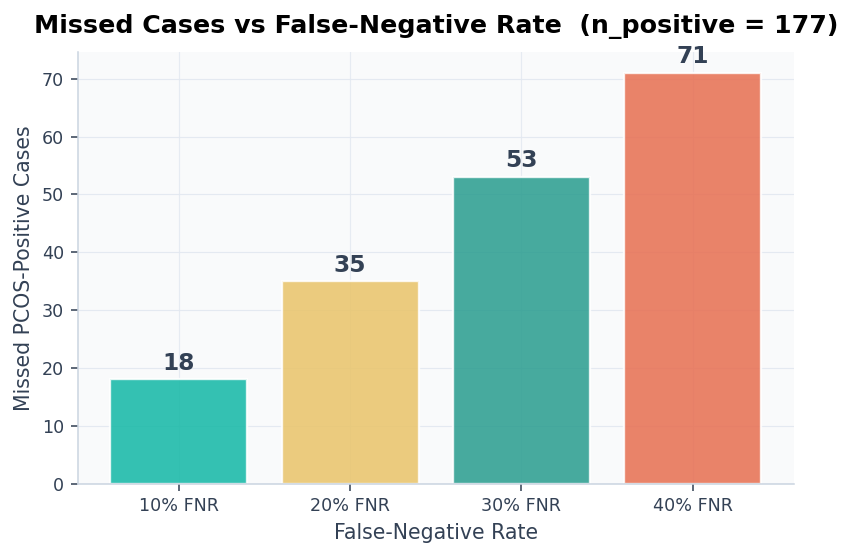

In [39]:
n_pos = int((df['pcos_y_n']==1).sum())
fnr_range = [0.10, 0.20, 0.30, 0.40]
summary_q36 = pd.DataFrame({
    'false_negative_rate':  fnr_range,
    'assumed_sensitivity':  [1-r for r in fnr_range],
    'missed_positive_cases':[int(round(n_pos*r)) for r in fnr_range],
})
display(summary_q36)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
bar_colors = [PALETTE['teal'], PALETTE['accent'][1], PALETTE['accent'][0], PALETTE['pos']]
labels = [f'{int(r*100)}% FNR' for r in fnr_range]
bars = ax.bar(labels, summary_q36['missed_positive_cases'],
              color=bar_colors, alpha=0.86, edgecolor='white', linewidth=1.2)
for bar, n in zip(bars, summary_q36['missed_positive_cases']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            str(n), ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=PALETTE['slate'])
ax.set_xlabel('False-Negative Rate')
ax.set_ylabel('Missed PCOS-Positive Cases')
ax.set_title(f'Missed Cases vs False-Negative Rate  (n_positive = {n_pos})')
finish(ax)
save_figure(fig, 'q36_false_negative_cost.png')
plt.show()


### Insight
**Scientific interpretation:** The missed-case bar chart converts class imbalance into a clinically understandable consequence: even moderate false-negative rates lead to a sizeable number of missed positive patients. With 177 positives in the cohort, a 20 percent false-negative rate corresponds to roughly 35 missed cases.

**Simple summary:** Missing even a small share of positive cases quickly becomes a real clinical problem.

**Why this matters:** Later evaluation should emphasize recall, sensitivity, and miss-cost rather than celebrating raw accuracy alone.


### Section Synthesis
**Cross-chart reading:** Correlation, cross-tabulation, engineered BMI categories, and the burden score all reinforce the same message: signal is accumulating in a connected group of adiposity, symptom, and ovarian features rather than in isolated vital signs.

**How the findings relate:** The notebook is therefore converging on a coherent PCOS phenotype rather than a set of unrelated one-off associations.

**Practical interpretation:** The next modelling stage should emphasize recall-sensitive screening with carefully chosen non-invasive features, then test whether invasive ovarian or hormonal additions truly improve performance.


## 10 ? Observational Summary

**Observational summary:** The clinical notebook is showing a coherent PCOS phenotype built around higher body mass, altered menstrual recording patterns, stronger visible symptom burden, and markedly heavier ovarian follicle counts. BMI, weight gain, hair growth, skin darkening, pimples, cycle_regularity_code, and follicle counts are repeatedly separating the positive group, while pulse rate, respiratory rate, haemoglobin, and both blood pressure measures remain far more stable across classes.

**Simple wrap-up:** In plain language, PCOS-positive participants in this dataset tend to look heavier, report more visible symptoms and cycle disruption, and show much larger follicle counts. Basic vital signs are not driving the story.

**Feature usefulness interpretation:**
**Stronger signals:** `bmi`, `weight_kg`, `weight_gain_y_n`, `hair_growth_y_n`, `skin_darkening_y_n`, `pimples_y_n`, `cycle_regularity_code`, `cycle_length_days` as a recorded measure, `follicle_no_left`, `follicle_no_right`, `non_invasive_burden_score`
**Moderate or supporting signals:** `rbs_mg_dl`, `hair_loss_y_n`, `endometrium_mm`, `avg_follicle_size_right_mm`, `waist_hip_ratio`
**Weak or background signals:** `age_yrs`, `pulse_rate_bpm`, `respiratory_rate_breaths_min`, `hb_g_dl`, `systolic_bp_mmhg`, `diastolic_bp_mmhg`, `regular_exercise_y_n`
**Features to treat carefully:** `fast_food_y_n` and other lifestyle proxies may carry real signal, but they are also more vulnerable to behavioural factor that can distort the comparisoning and reporting bias.
